# PIR UE9 - Séance 6 :

## __Transcriptomique : Analyses exploratoires et analyse d'expression différentielle__

Sandrine Caburet

*d'après plusieurs TPs d'analyses bioinformatique du M1 Génétique,  
avec des données générées par Yves Clément* 

**Tutoriel**

Nous allons ici analyser des données de transcriptomique de type "bulk RNAseq", obtenus à partir d'échantillons de cortex et de foie de souris adultes.

Les souris de ce dataset sont issues de 3 lignées differentes : Wild Type (WT), Duplication (Dup) et Deletion (Del) d'une région du chromosome 7 murin synténique d'une région humaine impliquée dans l'autisme. Les échantillons de cortex ont fait l'objet d'une première étude en 2014 : Blumenthal et al. (AJHG 2014, DOI : 10.1016/j.ajhg.2014.05.004).

Ces données d'échantillons de cortex font partie d'un plus gros dataset souris qui a été publié en 2018 sur GEO (GSE76872) et dans SRA (PRJNA312352), qui a ensuite été utilisé pour les analyses présentées dans l'article Tai et al. (AJHG, 2022, 10.1016/j.ajhg.2022.08.012).

Les données disponibles regroupent tous les tissus étudiés (Cortex, Striatum (Corps strié), Cerebellum (Cervelet), Foie, Graisse blanche, Graisse brune) dans 16 souris : 8 WT, 4 Dup et 4 Del.

Nous allons analyser les données des RNAseq de foie et de cortex des souris Wild_Type.

Pour démarrer le pipeline d'analyse de ces données, notre collègue Yves Clément a préalablement récupéré les données de séquences brutes (raw reads) des échantillons. Tous les échantillons on été ré-analysés dans le même pipeline NF-Core récent, suivant ces différentes étapes : 
 - vérification des reads avec FastQC
 - préparation des reads avec Fastp
 - mapping sur le génome de référence de souris GRCm39 avec Star
 - comptage des reads à partir des bam avec Salmon (gene level) 
 
Nous allons donc partir de ces comptages de reads pour poursuivre l'analyse.  

**Dans ce tutoriel, nous allons voir comment :**  
 **- sélectionner des données correspondant à certains échantillons dans un gros dataset**   
 **- réaliser une analyse exploratoire des données de transcriptomique de type "bulk RNAseq"**   
 **- réaliser une analyse d'expression différentielle**   
 **- visualiser les résultats pour identifier les gènes DE les plus intéressants**  

## 0. Set up parameters and RSession
---

We start with setting up paths to directories.

In [1]:
## Code cell 1 ##

#setwd("~/meg_m1_gb_r")
myworking_path <- "./" # modify as necessary


We install required libraries and load them.

In [2]:
## Code cell 2 ##

# list the required libraries
requiredLib <- c(
    "statmod",
    "RColorBrewer",
    "dendextend",
    "stats",
    "grDevices",
    "BiocManager",
    "writexl",
    "ggnewscale",
    "ggupset",
    "writexl",
    "readxl",
    "ggridges",
    "MatrixGenerics",
    "gplots",
    "ggplot2",
    "ggrepel",
    "ggfortify")
requiredBiocLib <- c("DESeq2", 
                     "org.Mm.eg.db",
                     "clusterProfiler",
                     "enrichplot",
                     "ComplexHeatmap",
                     "ReactomePA",
                     "GenomicRanges",
                     "GenomeInfoDb",
                     "SummarizedExperiment",
                     "matrixStats",
                     "fgsea",
                     "data.table",
                     "sva")


# install required libraries if not
for (lib in requiredLib) {
  if (!require(lib, character.only = TRUE, quiet = TRUE)) {
    install.packages(lib, quiet = TRUE)
  }
}

for( lib in requiredBiocLib) {
  if (!require(lib, character.only = TRUE, quiet = TRUE)) {
  BiocManager::install(lib, quiet = TRUE)
  }
}

# load libraries
message("Loading required libraries")
for (lib in requiredLib) {
  library(lib, character.only = TRUE)}

for (lib in requiredBiocLib) {
  library(lib, character.only = TRUE)}


rm(lib, requiredLib, requiredBiocLib)


---------------------
Welcome to dendextend version 1.16.0
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree


Bioconductor version '3.14' is out-of-date; the current release version '3.22'
  is available with R version '4.5'; see https://bioconductor.org/install


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colColla

<div class="alert alert-block alert-warning"> <b> En cas d'erreur pour l'installations des librairies R : </b><br>
Si vous obtenez une erreur du type "path not writable", c'est parce que la commande n'arrive pas à trouver le dossier nécessaire dans votre home.  <br>   
Pour résoudre ce problème, passez la cellule 2bis suivante en code, lancez là, puis relancez la cellule de code 2.     
</div>

Et enfin, bonne pratique à toujours faire, nous gardons une trace des librairies chargées dans notre session :

In [3]:
## Code cell 3 ##

# keep tracks of R and packages for this study

sessionInfo()

R version 4.1.3 (2022-03-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 18.04.4 LTS

Matrix products: default
BLAS/LAPACK: /srv/conda/envs/notebook/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] sva_3.42.0                  BiocParallel_1.28.3        
 [3] genefilter_1.76.0           mgcv_1.8-41                
 [5] nlme_3.1-160                data.table_1.14.4          
 [7] fgsea_1.20.0                ReactomePA_1.38.0          
 [9] ComplexHeatmap_2.10.0       enrichplot_1.1

## 1. Chargement des Data
---


**Data Cortex et Foie - Souris - Blumenthal-2014/Tai-2022**

Article Tai et al. (AJHG, 2022, 10.1016/j.ajhg.2022.08.012).    

Les données disponibles regroupent tous les tissus étudiés (Cortex, Striatum (Corps strié), Cerebellum (Cervelet), Foie, Graisse blanche, Graisse brune) dans 16 souris : 8 WT, 4 Dup et 4 Del. 

Nous allons récupérer les données des RNAseq de foie et de cortex, uniquement pour les souris Wild_Type.

### 1.A - Metadata Blumenthal-2014/Tai-2022

Les metadata sont obtenues depuis SRA (PRJNA312352, info accessible en partant par exemple de la page GEO dataset correspondant au projet : GSE76872), et en sélectionnant les échantillons qui nous intéressent.   
Ici un fichier global a été récupéré depuis SRA Run Selector. Il contient les informations sur les 96 échantillons (16 souris x 6 tissus). 

In [4]:
## Code cell 4 ##

# Chargement des métadonnées
metadataTai <- read.table("/srv/data/meg-m1-gb/RNAseq/Tai-2022/SraRunTable-mmu-Blumenthal2014.csv",
                       header = TRUE, sep = ",", stringsAsFactors = FALSE)

# Afficher les premières lignes
str(metadataTai)
dim(metadataTai)
head(metadataTai, 4)

'data.frame':	96 obs. of  35 variables:
 $ Run                : chr  "SRR3175324" "SRR3175325" "SRR3175326" "SRR3175327" ...
 $ AGE                : chr  "Post Natal day 59" "Post Natal day 59" "Post Natal day 68" "Post Natal day 68" ...
 $ animal_id          : chr  "T1979" "T1980" "T1981" "T1982" ...
 $ Assay.Type         : chr  "RNA-Seq" "RNA-Seq" "RNA-Seq" "RNA-Seq" ...
 $ AvgSpotLen         : int  102 102 102 102 102 102 102 102 102 102 ...
 $ Bases              : num  3.29e+09 3.38e+09 3.65e+09 3.45e+09 3.89e+09 ...
 $ BioProject         : chr  "PRJNA312352" "PRJNA312352" "PRJNA312352" "PRJNA312352" ...
 $ BioSample          : chr  "SAMN04503809" "SAMN04503810" "SAMN04503811" "SAMN04503812" ...
 $ Bytes              : num  2.16e+09 2.21e+09 2.50e+09 2.37e+09 2.54e+09 ...
 $ Center.Name        : chr  "GEO" "GEO" "GEO" "GEO" ...
 $ Consent            : chr  "public" "public" "public" "public" ...
 $ DATASTORE.filetype : chr  "fastq,run.zq,sra" "fastq,run.zq,sra" "fastq,run.zq,sra" "

[1] 96 35

,Run,AGE,animal_id,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,⋯,Organism,Platform,ReleaseDate,Sample.Name,source_name,SRA.Study,strain,tissue,create_date,version
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,SRR3175324,Post Natal day 59,T1979,RNA-Seq,102,3293910786,PRJNA312352,SAMN04503809,2162306094,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039209,BrownFat,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,BrownFat,2016-02-17T12:47:00Z,1
2,SRR3175325,Post Natal day 59,T1980,RNA-Seq,102,3384200064,PRJNA312352,SAMN04503810,2209283471,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039210,BrownFat,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,BrownFat,2016-02-17T13:06:00Z,1
3,SRR3175326,Post Natal day 68,T1981,RNA-Seq,102,3654696822,PRJNA312352,SAMN04503811,2500093782,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039211,BrownFat,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,BrownFat,2016-02-17T12:56:00Z,1
4,SRR3175327,Post Natal day 68,T1982,RNA-Seq,102,3451326366,PRJNA312352,SAMN04503812,2367013740,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039212,BrownFat,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,BrownFat,2016-02-17T12:54:00Z,1


On voit que les infos qui nous intéressent pour le tri sont dans les colonnes : 
 - genotype pour la condition
 - tissue ou source_name pour le tissu d'intérêt
 - animal_id pour le numéro de la souris
 - gender pour le sexe de l'animal

On commence par ne récuperer que les lignes qui nous intéressent : 

In [5]:
## Code cell 5 ##

# Filtrer les lignes où 'genotype' est "Wild Type" et 'source_name' est "Cortex" ou "Liver"
metadataTai_wt <- metadataTai[
  metadataTai$genotype == "Wild Type" & (metadataTai$source_name %in% c("Cortex", "Liver")),
  ]
head(metadataTai_wt, 4)


,Run,AGE,animal_id,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center.Name,⋯,Organism,Platform,ReleaseDate,Sample.Name,source_name,SRA.Study,strain,tissue,create_date,version
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
33,SRR3175356,Post Natal day 59,T1979,RNA-Seq,100,4746369900,PRJNA312352,SAMN04503781,3230320093,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039241,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,2016-02-17T13:09:00Z,1
34,SRR3175357,Post Natal day 59,T1980,RNA-Seq,100,3819799500,PRJNA312352,SAMN04503782,2595210033,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039242,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,2016-02-17T13:00:00Z,1
35,SRR3175358,Post Natal day 68,T1981,RNA-Seq,100,4701292600,PRJNA312352,SAMN04503788,3213498545,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039243,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,,NA
36,SRR3175359,Post Natal day 68,T1982,RNA-Seq,100,4531549900,PRJNA312352,SAMN04503729,3085588806,GEO,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039244,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,2016-02-17T12:39:00Z,1


On ajoute une colonne avec un nom plus facile à gérer, qui prend en compte le tissu, le sexe et l'identifiant de la souris.

In [6]:
## Code cell 6 ##

# Créer la colonne sample_name basée sur le design expérimental
metadataTai_wt$sample_name <- with(metadataTai_wt, {
  # Déterminer le tissu 
  tissue <- ifelse(source_name == "Cortex", "Cortex",
            ifelse(source_name == "Liver", "Liver", NA))
  
  # Déterminer l'initiale du sexe
  g <- ifelse(tolower(gender) == "male", "m",
       ifelse(tolower(gender) == "female", "f", NA))
  
  # Déterminer le numéro de réplicat (basé sur erccmix)
  rep <- as.integer(ave(Experiment, tissue, g,
                        FUN = function(x) rank(x, ties.method = "first")))
  
  # Créer le nom de l'échantillon
  paste0(tissue, "_", g, rep)
})

# Placer sample_name en première colonne
metadataTai_wt <- metadataTai_wt[, c("sample_name", setdiff(names(metadataTai_wt), "sample_name"))]

# Renommer "Wild Type" en "Wild_Type"
metadataTai_wt$genotype <- factor(gsub("Wild Type", "Wild_Type", metadataTai_wt$genotype))                    
                    
head(metadataTai_wt, 3)

,sample_name,Run,AGE,animal_id,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,⋯,Organism,Platform,ReleaseDate,Sample.Name,source_name,SRA.Study,strain,tissue,create_date,version
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
33,Cortex_f1,SRR3175356,Post Natal day 59,T1979,RNA-Seq,100,4746369900,PRJNA312352,SAMN04503781,3230320093,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039241,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,2016-02-17T13:09:00Z,1
34,Cortex_f2,SRR3175357,Post Natal day 59,T1980,RNA-Seq,100,3819799500,PRJNA312352,SAMN04503782,2595210033,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039242,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,2016-02-17T13:00:00Z,1
35,Cortex_m1,SRR3175358,Post Natal day 68,T1981,RNA-Seq,100,4701292600,PRJNA312352,SAMN04503788,3213498545,⋯,Mus musculus,ILLUMINA,2018-10-02T00:00:00Z,GSM2039243,Cortex,SRP070440,B6129S-Dp(7Slx1b-Sept1)5Aam/J,Cortex,,NA


On vérifie rapidement que chaque animal (par exemple f1 ou m2) est bien présent 2 fois, une fois pour le Cortex et une seconde fois pour le foie : 

In [7]:
## Code cell 7 ##

metadataTai_wt$sample_name

[1] "Cortex_f1" "Cortex_f2" "Cortex_m1" "Cortex_m2" "Cortex_m3" "Cortex_m4"
 [7] "Cortex_f3" "Cortex_f4" "Liver_f1"  "Liver_f2"  "Liver_m1"  "Liver_m2" 
[13] "Liver_m3"  "Liver_m4"  "Liver_f3"  "Liver_f4"

### 1.B - Counts data de Blumenthal-2014/Tai-2022

Les données de reads counts sont dans un fichier produit par Salmon à partir des bam générés par Star : "salmon.merged.gene_counts.tsv".   


In [8]:
## Code cell 8 ##

# Chargement des données
countsTai <- read.table("/srv/data/meg-m1-gb/RNAseq/Tai-2022/mappingResults/star_salmon/salmon.merged.gene_counts.tsv",
                       header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Afficher les premières lignes
str(countsTai)
head(countsTai,3)
dim(countsTai)

'data.frame':	78317 obs. of  98 variables:
 $ gene_id   : chr  "ENSMUSG00000000001.5" "ENSMUSG00000000003.16" "ENSMUSG00000000028.16" "ENSMUSG00000000031.20" ...
 $ gene_name : chr  "Gnai3" "Pbsn" "Cdc45" "H19" ...
 $ SRX1589793: num  4204 0 293 392 148 ...
 $ SRX1589794: num  1071 0 78 62396 24 ...
 $ SRX1589795: num  1043 0 107 518 8 ...
 $ SRX1589796: num  952 0 98 9759 13 ...
 $ SRX1589797: num  1197 0 174 432 9 ...
 $ SRX1589798: num  1702 0 137 26567 43 ...
 $ SRX1589799: num  1191 0 136 3975 6 ...
 $ SRX1589800: num  757 0 82 16816 10 ...
 $ SRX1589801: num  1343 0 171 44 17 ...
 $ SRX1589802: num  1058 0 119 142 12 ...
 $ SRX1589803: num  919 0 137 71 5 ...
 $ SRX1589804: num  1043 0 113 2604 10 ...
 $ SRX1589805: num  1455 0 191 350 10 ...
 $ SRX1589806: num  680 0 149 17003 9 ...
 $ SRX1589807: num  804 0 80 1845 3 ...
 $ SRX1589808: num  365 0 49 16201 7 ...
 $ SRX1589809: num  1128 0 74 55 15 ...
 $ SRX1589810: num  1016 0 69 63 13 ...
 $ SRX1589811: num  1059 0 80 38 15 ..

,gene_id,gene_name,SRX1589793,SRX1589794,SRX1589795,SRX1589796,SRX1589797,SRX1589798,SRX1589799,SRX1589800,⋯,SRX1589879,SRX1589880,SRX1589881,SRX1589882,SRX1589883,SRX1589884,SRX1589885,SRX1589886,SRX1589887,SRX1589888
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSMUSG00000000001.5,Gnai3,4204,1071,1043.000,952,1197,1702,1191,757,⋯,3555,2651,4145,3997,1904,1852,2543,680.000,1904.000,2316
2,ENSMUSG00000000003.16,Pbsn,0,0,0.000,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0.000,0.000,0
3,ENSMUSG00000000028.16,Cdc45,293,78,107.001,98,174,137,136,82,⋯,76,155,136,111,145,76,164,139.999,104.999,88


[1] 78317    98

On extrait les colonnes qui nous intéressent pour n'avoir que les counts des échantillons WT, c'est à dire ceux dont les noms sont dans `metadataTai_wt`.

In [9]:
## Code cell 9 ##

countsTai_wt <- subset(countsTai, select = metadataTai_wt$Experiment)

# rétablissement des valeurs de read counts sous la forme d'entiers
countsTai_wt[] <- lapply(countsTai_wt, as.integer)

On renomme les échantillons pour avoir des noms plus faciles à gérer : 

In [10]:
## Code cell 10 ##

# Créer un vecteur de correspondance entre Experiment et sample_name depuis metadataTai_wt
names <- setNames(metadataTai_wt$sample_name, metadataTai_wt$Experiment)
names

# Renommer les colonnes de countsTai_wt en utilisant ce vecteur
colnames(countsTai_wt) <- names[colnames(countsTai_wt)]



SRX1589825  SRX1589826  SRX1589827  SRX1589828  SRX1589833  SRX1589834 
"Cortex_f1" "Cortex_f2" "Cortex_m1" "Cortex_m2" "Cortex_m3" "Cortex_m4" 
 SRX1589835  SRX1589836  SRX1589841  SRX1589842  SRX1589843  SRX1589844 
"Cortex_f3" "Cortex_f4"  "Liver_f1"  "Liver_f2"  "Liver_m1"  "Liver_m2" 
 SRX1589849  SRX1589850  SRX1589851  SRX1589852 
 "Liver_m3"  "Liver_m4"  "Liver_f3"  "Liver_f4"

On remet les noms de gènes devant les reads counts : 

In [11]:
## Code cell 11 ##

countsTai_wt <- cbind(countsTai[, 1:2], countsTai_wt)

In [12]:
## Code cell 12 ##

dim(countsTai_wt)
head(countsTai_wt, 3)

[1] 78317    18

,gene_id,gene_name,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ENSMUSG00000000001.5,Gnai3,1230,922,1228,1186,1268,666,1091,703,2825,2077,3016,3399,3293,3109,3010,2859
2,ENSMUSG00000000003.16,Pbsn,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,ENSMUSG00000000028.16,Cdc45,49,42,57,33,65,34,51,26,31,17,15,26,25,31,22,32


### 1.C - Fichier de metadata pour notre analyse

On crée un dataframe `metadata` pour avoir les infos nécessaires sur ces échantillons, qui sera plus simple à manipuler.

In [13]:
## Code cell 13 ##

metadata <- data.frame(
  sample_id = metadataTai_wt$sample_name,
  study = "Tai-2022",
  rnaseq = "stranded_PE", 
  genotype = as.character(metadataTai_wt$genotype),
  tissue = metadataTai_wt$source_name,  
  sex = metadataTai_wt$gender,
  replicate = as.integer(substr(metadataTai_wt$sample_name,nchar(metadataTai_wt$sample_name),nchar(metadataTai_wt$sample_name))),
  stringsAsFactors = FALSE
)

metadata

sample_id,study,rnaseq,genotype,tissue,sex,replicate
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
Cortex_f1,Tai-2022,stranded_PE,Wild_Type,Cortex,female,1
Cortex_f2,Tai-2022,stranded_PE,Wild_Type,Cortex,female,2
Cortex_m1,Tai-2022,stranded_PE,Wild_Type,Cortex,male,1
Cortex_m2,Tai-2022,stranded_PE,Wild_Type,Cortex,male,2
Cortex_m3,Tai-2022,stranded_PE,Wild_Type,Cortex,male,3
Cortex_m4,Tai-2022,stranded_PE,Wild_Type,Cortex,male,4
Cortex_f3,Tai-2022,stranded_PE,Wild_Type,Cortex,female,3
Cortex_f4,Tai-2022,stranded_PE,Wild_Type,Cortex,female,4
Liver_f1,Tai-2022,stranded_PE,Wild_Type,Liver,female,1


A l'issue du chargement des données, on peut lister les éléments chargés dans notre session, et supprimer ceux qui ne sont plus utiles.

In [14]:
## Code cell 14 ##

ls()

[1] "countsTai"      "countsTai_wt"   "metadata"       "metadataTai"   
[5] "metadataTai_wt" "myworking_path" "names"

In [15]:
## Code cell 15 ##

rm(countsTai, metadataTai, metadataTai_wt, names)

-------

## 2. Exploration initiale des données brutes

### 2.A - Distribution des reads counts

Avant toute normalisation, nous examinons la distribution des read counts bruts.

In [16]:
## Code cell 16 ##

dim(countsTai_wt)
#summary(countsTot)

# Statistiques descriptives des read counts
summary(colSums(countsTai_wt[ ,3:18], na.rm=TRUE))
summary(rowSums(countsTai_wt[ ,3:18], na.rm=TRUE))

[1] 78317    18

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
21145688 27591132 30364562 30217975 33478858 38949694 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
       0        0        1     6173      105 16802361 


<div class="alert alert-block alert-info"> <b> Question 1 : </b><br>
<b> - Que pensez vous de cette distribution ? <br>
    - Les données vous semblent-elles être brutes ou normalisées ? </b> </div>
___ (ajoutez une cellule Markdown en dessous pour taper votre réponse)

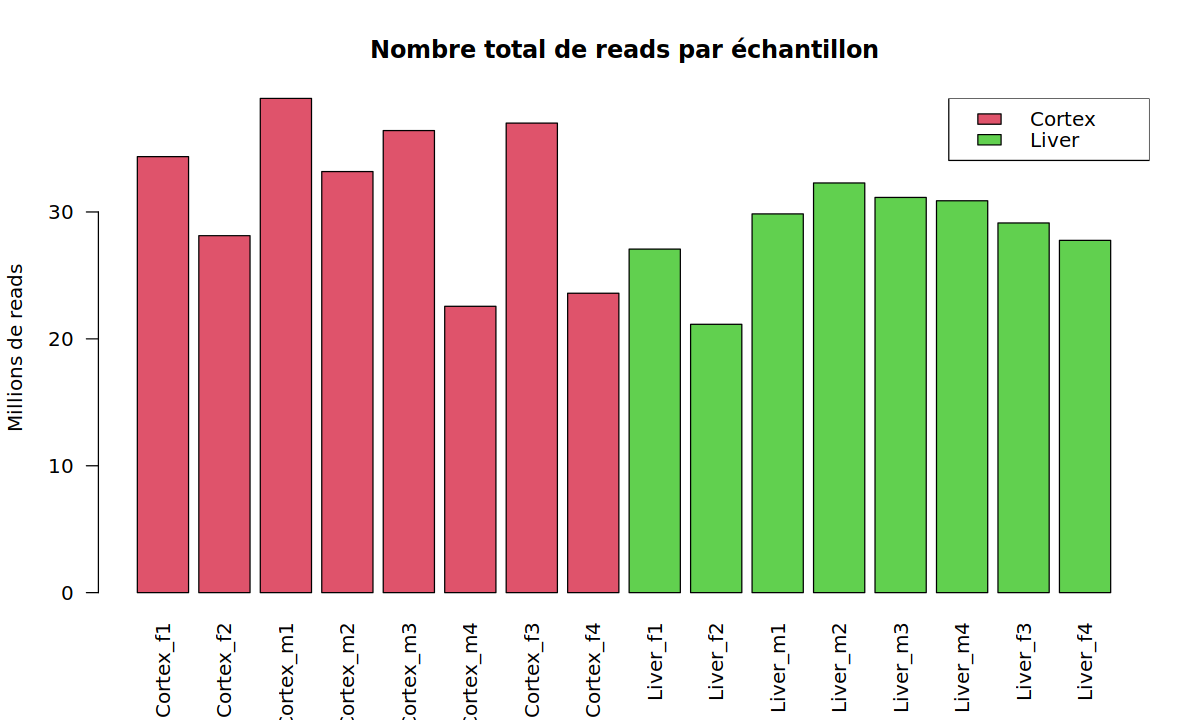

In [17]:
## Code cell 17 ##

options(repr.plot.width = 10, repr.plot.height = 6)

# create a colour vector to color samples by tissue
tissueColor <- match(metadata$tissue, c("Cortex", "Liver")) + 1
# '+1' to avoid color '1' i.e. black

# Visualisation de la distribution des read counts totaux par échantillon
barplot(colSums(countsTai_wt[ ,3:18], na.rm=TRUE)/1e6, 
        las = 2, 
        main = "Nombre total de reads par échantillon",
        ylab = "Millions de reads",
        col = tissueColor)
legend("topright", 
       legend = levels(factor(metadata$tissue)),
       fill = 2:3)


<div class="alert alert-block alert-info"> <b> Question 2 : </b><br>
<b> - Quelle est l'origine de la variation observée entre les échantillons ? <br>
    - Comment cette variabilité va t'elle être prise en compte dans la suite de l'analyse ? </b> </div>
___ 

### 2.B - Préfiltrage des gènes faiblement exprimés

Nous retirons les gènes avec très peu de reads pour améliorer la qualité de l'analyse et réduire le temps de calcul. 
Pour déterminer le seuil à utiliser, il est courant de prendre le nombre d'échantillons - 1. Enlever tous les gènes qui ont un read count total inférieur au nombre d'échantillon veut dire qu'aucun echantillon du dataset ne présente une expression au-delà de quelques reads.   

Ici, nous avons 16 échantillons, nous prenons donc un seuil de 15.

Un seuil minimal de 15 reads au total sur tous les échantillons est appliqué.

In [18]:
## Code cell 18 ##

# Filtrer les gènes avec moins de 10 reads au total
keep <- rowSums(countsTai_wt[ ,3:18], na.rm=TRUE) >= 15
counts_filtered <- countsTai_wt[keep, ]

#summary(keep)

# Afficher le nombre de gènes conservés
cat("Gènes avant filtrage:", nrow(countsTai_wt), "\n")
cat("Gènes après filtrage:", nrow(counts_filtered), "\n")
cat("Gènes retirés:", sum(!keep), "\n")

Gènes avant filtrage: 78317 
Gènes après filtrage: 26709 
Gènes retirés: 51608 



<div class="alert alert-block alert-info"> <b> Question 3 : </b><br>
<b> - Est-ce que le nombre de gènes éliminés vous semble important ? Logique ? <br>
    - Pourquoi ? </b> </div>
___ 

In [19]:
## Code cell 19 ##

dim(counts_filtered)
head(counts_filtered)

[1] 26709    18

,gene_id,gene_name,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ENSMUSG00000000001.5,Gnai3,1230,922,1228,1186,1268,666,1091,703,2825,2077,3016,3399,3293,3109,3010,2859
3,ENSMUSG00000000028.16,Cdc45,49,42,57,33,65,34,51,26,31,17,15,26,25,31,22,32
4,ENSMUSG00000000031.20,H19,9,0,4,3,1,4,4,2,18,1808,5,169,7,3,7,8
5,ENSMUSG00000000037.18,Scml2,74,61,59,62,53,33,52,36,1,4,0,2,1,2,6,6
6,ENSMUSG00000000049.12,Apoh,7,8,10,11,16,11,5,4,39589,34224,51699,44869,43115,46534,53803,47560
7,ENSMUSG00000000056.8,Narf,1816,1273,1939,1783,1753,1051,1906,1067,1038,892,1541,2376,1483,1502,1464,1282


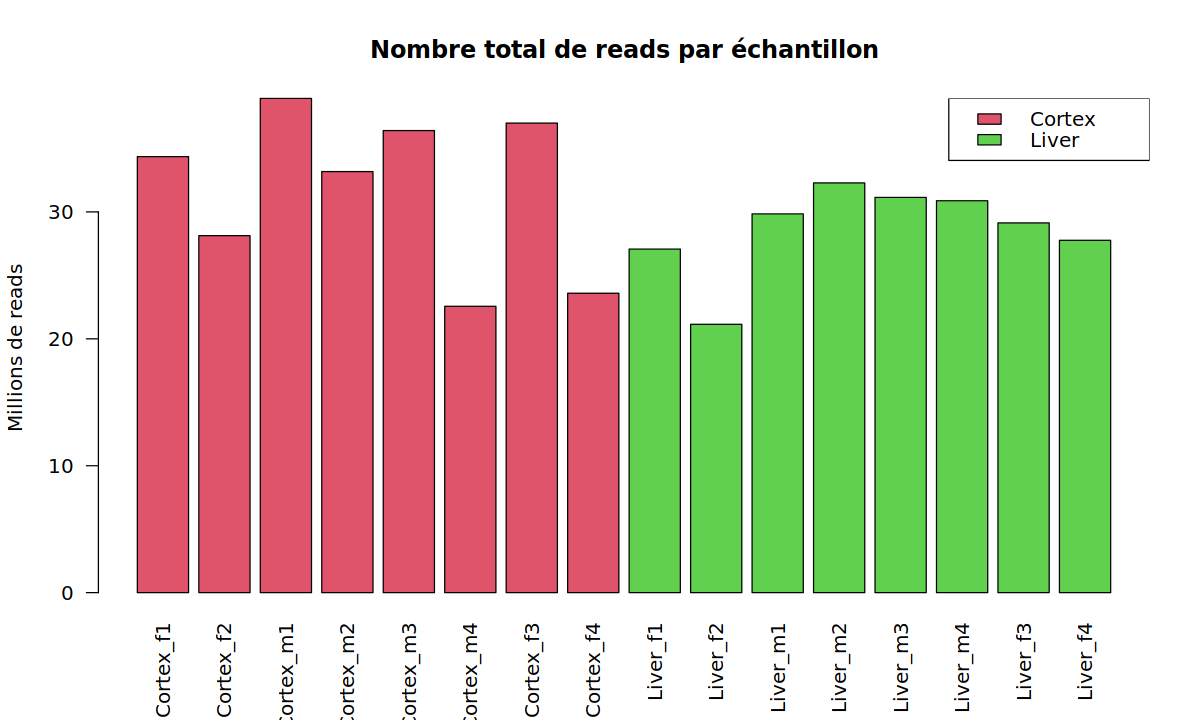

In [20]:
## Code cell 20 ##

options(repr.plot.width = 10, repr.plot.height = 6)

# create a colour vector to color samples by tissue
tissueColor <- match(metadata$tissue, c("Cortex", "Liver")) + 1
# '+1' to avoid color '1' i.e. black

# Visualisation de la distribution des read counts filtrés par échantillon
barplot(colSums(counts_filtered[ ,3:18], na.rm=TRUE)/1e6, 
        las = 2, 
        main = "Nombre total de reads par échantillon",
        ylab = "Millions de reads",
        col = tissueColor)
legend("topright", 
       legend = levels(factor(metadata$tissue)),
       fill = 2:3)


<div class="alert alert-block alert-info"> <b> Question 4 : </b><br>
<b> - Ce graphe est-il différent de celui obtenu avec la cellule 17 ? <br>
    - Pourquoi ? </b> </div>
___ 

Il est très souvent utilie de visualiser la distribution des valeurs d'expression avec un boxplot : 

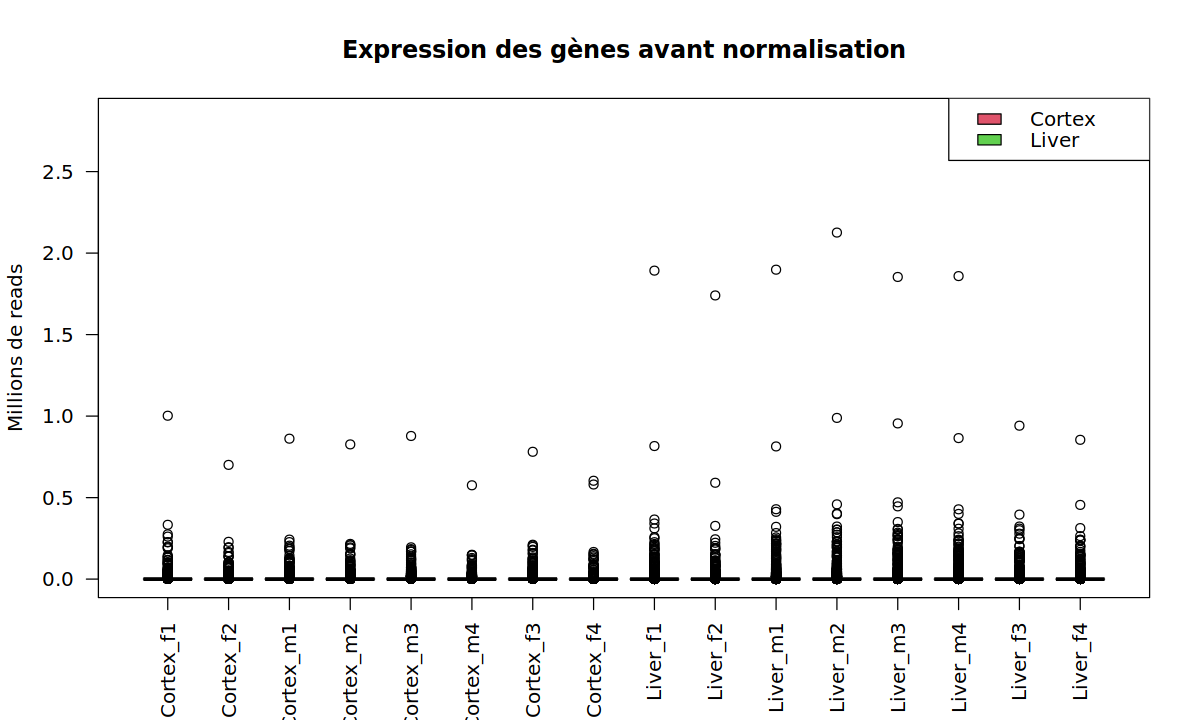

In [21]:
## Code cell 21 ##

options(repr.plot.width = 10, repr.plot.height = 6)

# create a colour vector to color samples by tissue
tissueColor <- match(metadata$tissue, c("Cortex", "Liver")) + 1
# '+1' to avoid color '1' i.e. black

# Visualisation de la distribution des read counts filtrés par échantillon
boxplot(counts_filtered[ ,3:18]/1e6, na.rm=TRUE, 
        las = 2,    # allows to change the orientation of the axis labels: 2 is for always perpendicular
        main = "Expression des gènes avant normalisation",
        ylab = "Millions de reads",
        col = tissueColor)
legend("topright", 
       legend = levels(factor(metadata$tissue)),
       fill = 2:3)


<div class="alert alert-block alert-info"> <b> Question 5 : </b><br>
<b> - Pourquoi les distributions sont-elles tassées vers le bas ? <br>
    - A quoi correspondent les ronds isolés au-dessus ? </b> </div>
___ 

Comme on s'y attend, il y a beaucoup de très faibles valeurs, on choisit donc de faire ce boxplot avec les valeurs d'expression passées en log2 : 

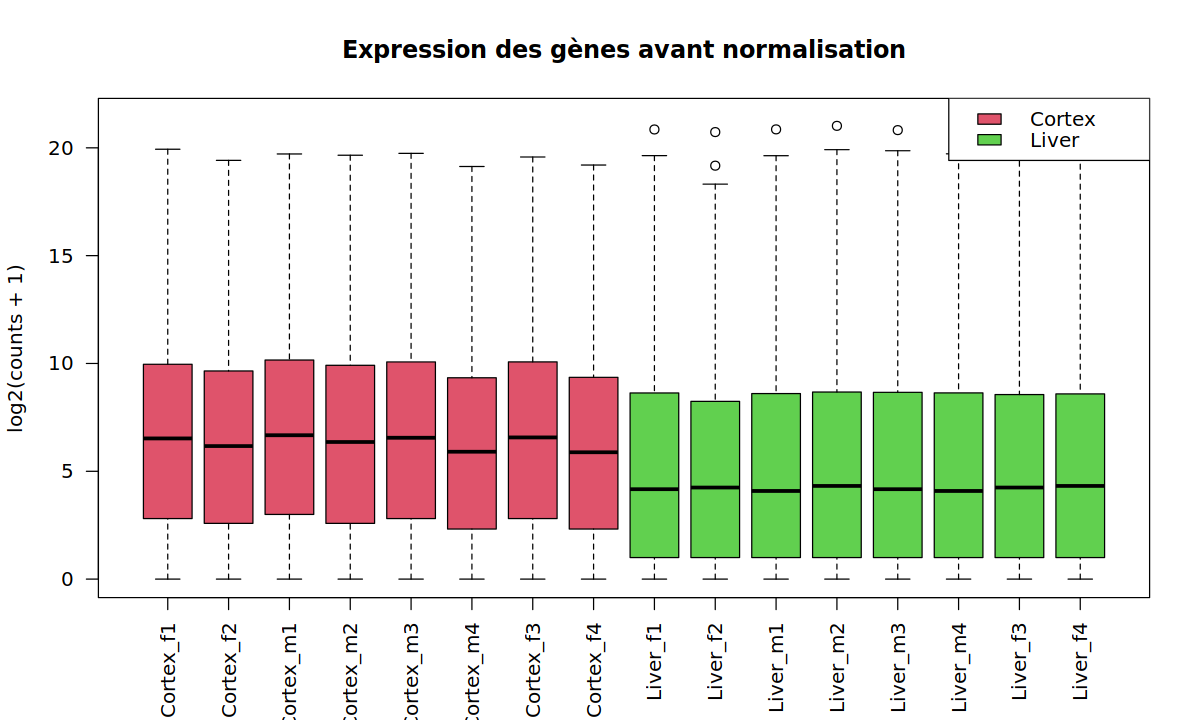

In [22]:
## Code cell 22 ##

options(repr.plot.width = 10, repr.plot.height = 6)

# create a colour vector to color samples by tissue
tissueColor <- match(metadata$tissue, c("Cortex", "Liver")) + 1
# '+1' to avoid color '1' i.e. black

# Visualisation de la distribution des read counts filtrés par échantillon
boxplot(log2(counts_filtered[ ,3:18]+1), 
        las = 2,    # allows to change the orientation of the axis labels: 2 is for always perpendicular
        main = "Expression des gènes avant normalisation",
        ylab = "log2(counts + 1)",
        col = tissueColor)
legend("topright", 
       legend = levels(factor(metadata$tissue)),
       fill = 2:3)


<div class="alert alert-block alert-info"> <b> Question 6 : </b><br>
<b> - A quoi correspondent les "boites" sur le graphes ? <br>
    - Les données vous semblent-elles être brutes ou normalisées ? </b> </div>
___ 

### 2.C - Analyse en Composantes Principales

#### a - Calcul de la PCA  

L'Analyse en Composantes Principales (ACP, ou PCA en anglais) permet de visualiser la structure globale des données et d'identifier les principales sources de variation entre les échantillons. Nous commençons par réaliser cette analyse sur toutes les données filtrées.

In [23]:
## Code cell 23 ##

# run PCA
PCAdata <- prcomp(t(counts_filtered[, -c(1:2)])) # we get rid of the first two columns of counts_filtered that do not contain count data
summary(PCAdata)

Importance of components:
                             PC1       PC2       PC3       PC4       PC5
Standard deviation     1.285e+06 2.837e+05 1.758e+05 1.171e+05 1.000e+05
Proportion of Variance 9.138e-01 4.455e-02 1.710e-02 7.590e-03 5.540e-03
Cumulative Proportion  9.138e-01 9.584e-01 9.755e-01 9.830e-01 9.886e-01
                             PC6       PC7       PC8       PC9      PC10
Standard deviation     8.130e+04 7.231e+04 5.355e+04 4.678e+04 3.534e+04
Proportion of Variance 3.660e-03 2.890e-03 1.590e-03 1.210e-03 6.900e-04
Cumulative Proportion  9.922e-01 9.951e-01 9.967e-01 9.979e-01 9.986e-01
                            PC11      PC12      PC13      PC14      PC15
Standard deviation     2.942e+04 2.843e+04 2.163e+04 1.439e+04 1.134e+04
Proportion of Variance 4.800e-04 4.500e-04 2.600e-04 1.100e-04 7.000e-05
Cumulative Proportion  9.991e-01 9.996e-01 9.998e-01 9.999e-01 1.000e+00
                            PC16
Standard deviation     7.173e-09
Proportion of Variance 0.000e+00

#### b - Diagrammes des éboulis

Les diagrammes des éboulis permettent de visualiser la relation entre les composantes de la PCA (ou "axes") et la part de la variance totale qu'elles représentent : 

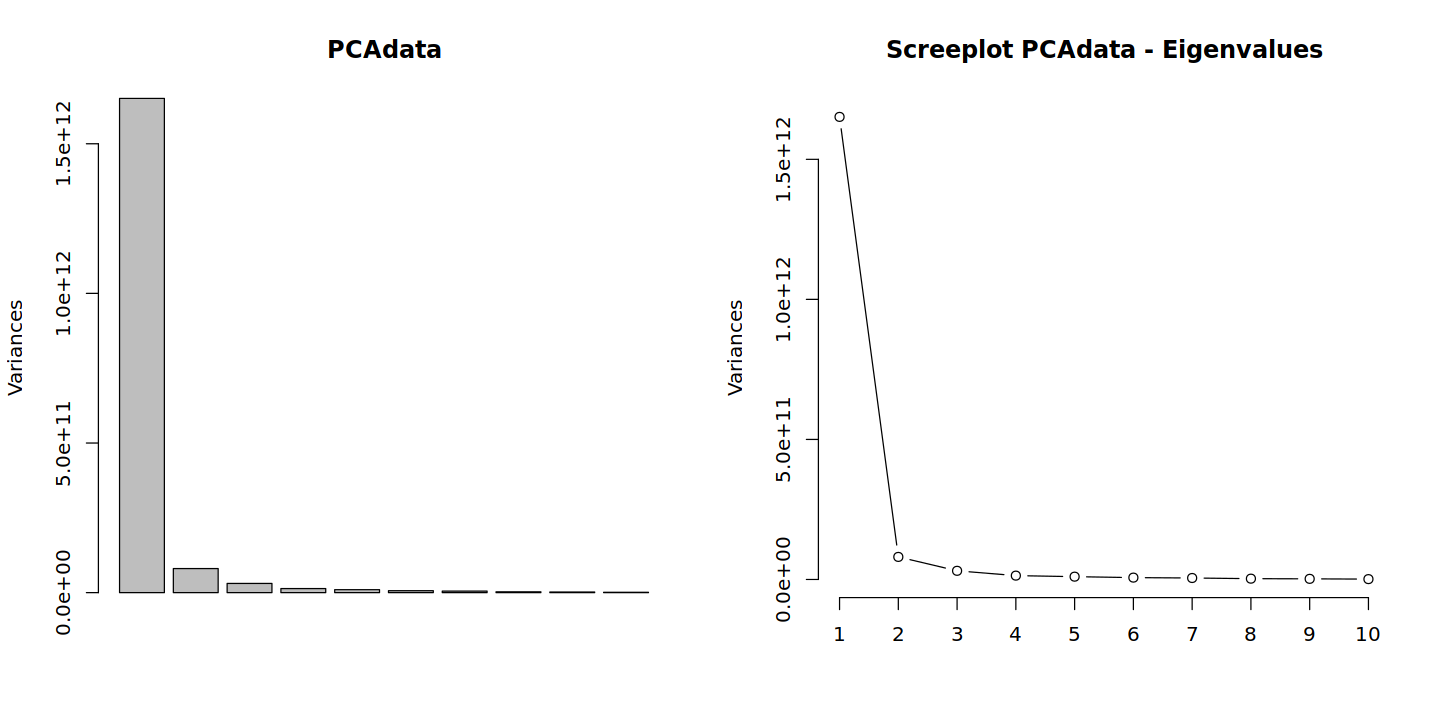

In [24]:
## Code cell 24 ##

options(repr.plot.width = 12, repr.plot.height = 6)

# to display the two scree plots side by side
layout(matrix(1:2, ncol = 2))

screeplot(PCAdata) # barplot representation
screeplot(PCAdata, type = "lines", main = "Screeplot PCAdata - Eigenvalues") # same but with a line

#### c - Plots de la PCA 

La visualisation des axes de la PCA permet de voir comment se répartissent les échantillons, et si une explication biologique soutend la part de variance expliquée par chaque composante.

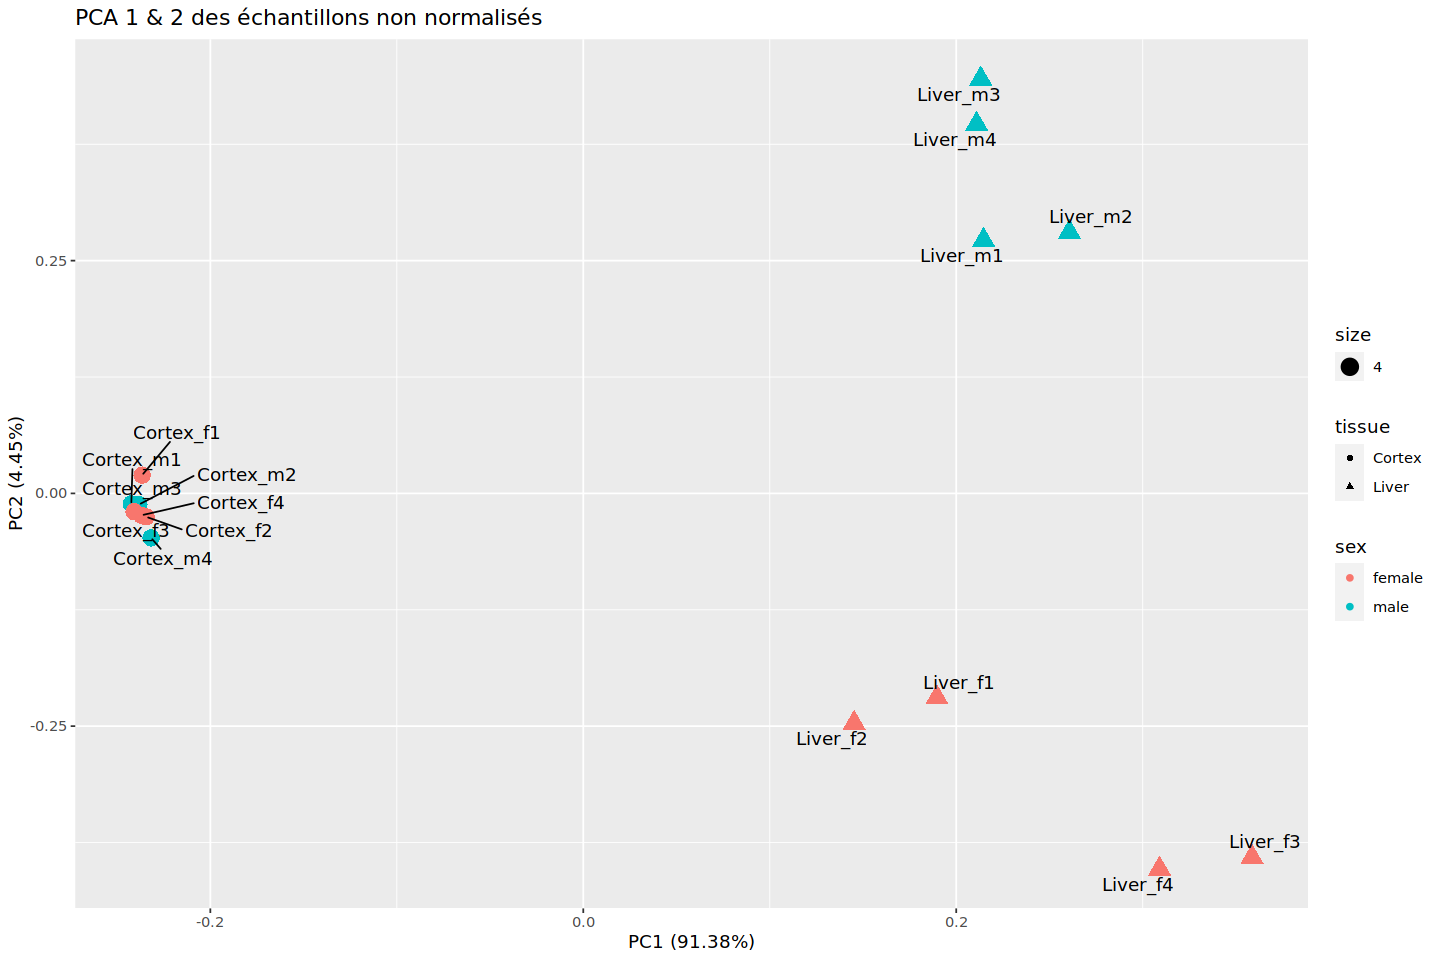

In [25]:
## Code cell 25 ##

options(repr.plot.width = 12, repr.plot.height = 8)

autoplot(PCAdata,
         data = metadata, 
         colour = "sex", 
         shape = "tissue",
         size = 4) +
        geom_text_repel(aes(x = PC1, y = PC2, label = sample_id), box.padding = 0.3, max.overlaps = 15) +
        labs(title = "PCA 1 & 2 des échantillons non normalisés")


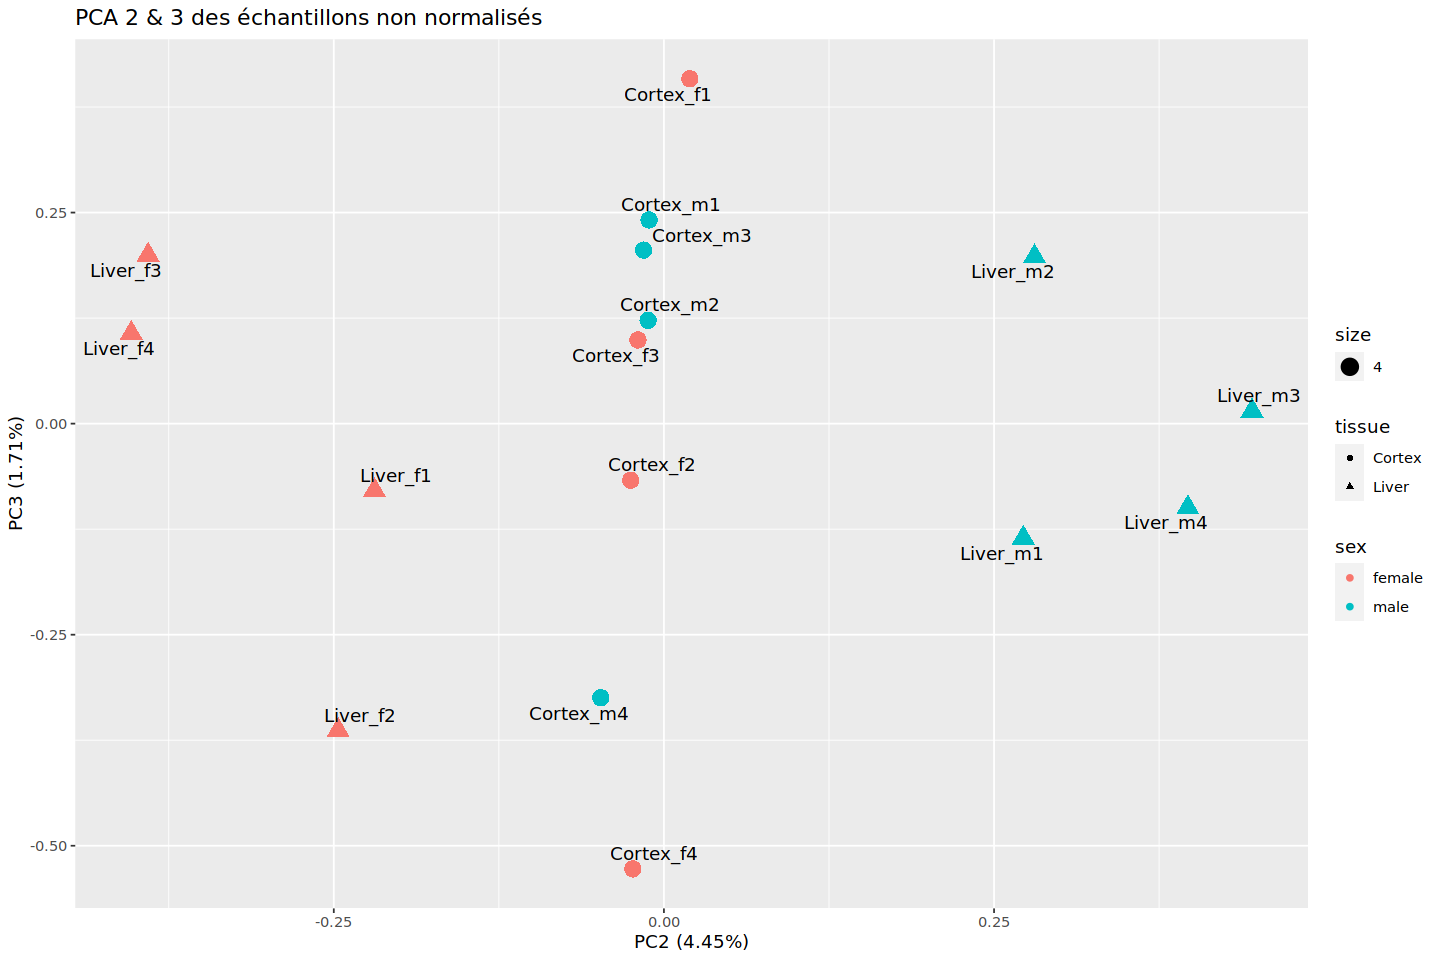

In [26]:
## Code cell 26 ##

options(repr.plot.width = 12, repr.plot.height = 8)

autoplot(PCAdata,
         x = 2,    # PC2
         y = 3,    # PC3
         data = metadata, 
         colour = "sex", 
         shape = "tissue",
         size = 4) +
        geom_text_repel(aes(x = PC2, y = PC3, label = sample_id), box.padding = 0.3, max.overlaps = 15) +
        labs(title = "PCA 2 & 3 des échantillons non normalisés")



<div class="alert alert-block alert-info"> <b> Question 7 : </b><br>
<b> - Quelle part de la variance total est-elle expliquée par la PC1 ? par la PC2 ? Par la PC3 ? <br>
    - Vous semblent-elles correspondre à une variation biologique ? Technique ? </b> </div>
___ 

### 2.D - PCA sur les gènes les plus variables   

#### a - Tri des gènes

Par définition, seuls les gènes dont l'expression varie contribuent à la différence entre les échantillons (variabilité biologique au sein des conditions) et à la différence entre les conditions testées (la différence qui nous intéresse).    
Par conséquent, la bonne pratique est de faire une PCA uniquement sur les gènes les plus variables. Nous allons donc sélectionner les gènes sur leur variance, puis refaire l'analyse PCA sur ceux-là seulement.

In [27]:
## Code cell 27

variances <- apply(counts_filtered[, -c(1:2)], 1, var)
sorted_var <- sort(variances, decreasing = TRUE)
top_300_genes <- names((sorted_var)[1:300])

On extrait les données des 300 gènes les plus variables :

In [28]:
## Code cell 28

counts_filtered300 <- counts_filtered[top_300_genes, ]
dim(counts_filtered300)
head(counts_filtered300)

[1] 300  18

,gene_id,gene_name,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
7244,ENSMUSG00000029368.11,Alb,1,1,1,3,3,0,2,0,1892462,1740241,1898250,2125915,1853592,1858955,2835594,2597341
9024,ENSMUSG00000032554.16,Trf,7842,6408,8997,7628,7318,4988,7353,4769,365603,326497,428672,458673,446228,399998,395726,455216
16480,ENSMUSG00000058207.7,Serpina3k,0,1,0,3,0,0,0,0,209997,147471,412764,398325,471041,428139,251424,87571
20269,ENSMUSG00000073842.11,Mup7,0,0,0,0,0,0,1,0,639,404,320718,402174,243688,339566,627,268
17864,ENSMUSG00000064351.1,mt-Co1,1002320,700776,861514,826451,878105,575549,781126,603426,816356,591102,813905,988908,955173,865100,941135,854590
52418,ENSMUSG00000119584.1,Rn18s-rs5,98050,74962,127915,106832,73600,47005,133194,580399,20259,22393,43668,50165,86675,99471,39871,23200


#### b - Calcul et plots de la PCA 

On refait l'analyse PCA sur les 300 gènes les plus variables : 

In [29]:
## Code cell 29 ##

# run PCA
PCAdata <- prcomp(t(counts_filtered300[, -c(1:2)])) # we get rid of the first two columns of counts_filtered that do not contain count data
summary(PCAdata)

Importance of components:
                             PC1       PC2       PC3       PC4       PC5
Standard deviation     1.272e+06 2.817e+05 1.678e+05 1.163e+05 9.886e+04
Proportion of Variance 9.155e-01 4.491e-02 1.594e-02 7.650e-03 5.530e-03
Cumulative Proportion  9.155e-01 9.604e-01 9.764e-01 9.840e-01 9.896e-01
                             PC6       PC7       PC8       PC9      PC10
Standard deviation     7.798e+04 7.034e+04 5.039e+04 4.118e+04 3.394e+04
Proportion of Variance 3.440e-03 2.800e-03 1.440e-03 9.600e-04 6.500e-04
Cumulative Proportion  9.930e-01 9.958e-01 9.972e-01 9.982e-01 9.989e-01
                            PC11      PC12      PC13      PC14      PC15
Standard deviation     2.676e+04 2.622e+04 1.929e+04 1.296e+04 8.833e+03
Proportion of Variance 4.100e-04 3.900e-04 2.100e-04 1.000e-04 4.000e-05
Cumulative Proportion  9.993e-01 9.997e-01 9.999e-01 1.000e+00 1.000e+00
                            PC16
Standard deviation     7.755e-11
Proportion of Variance 0.000e+00

##### Diagrammes des éboulis

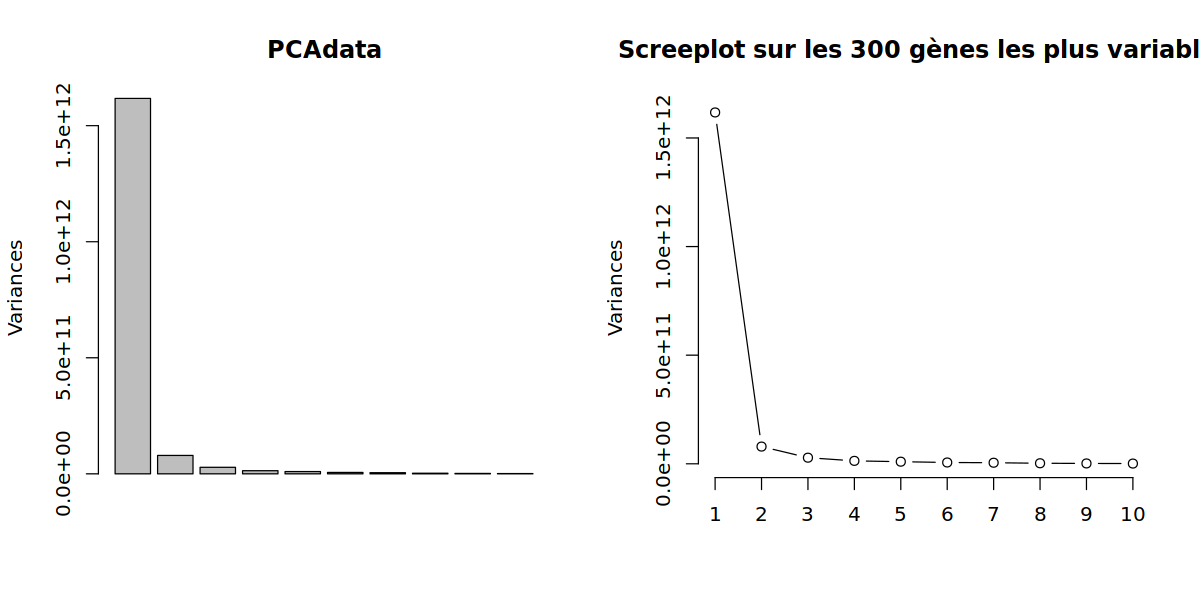

In [30]:
## Code cell 30 ##

options(repr.plot.width = 10, repr.plot.height = 5)

# to display the two scree plots side by side
layout(matrix(1:2, ncol = 2))

screeplot(PCAdata) # barplot representation
screeplot(PCAdata, type = "lines", main = "Screeplot sur les 300 gènes les plus variables") # same but with a line

##### Plots de la PCA 

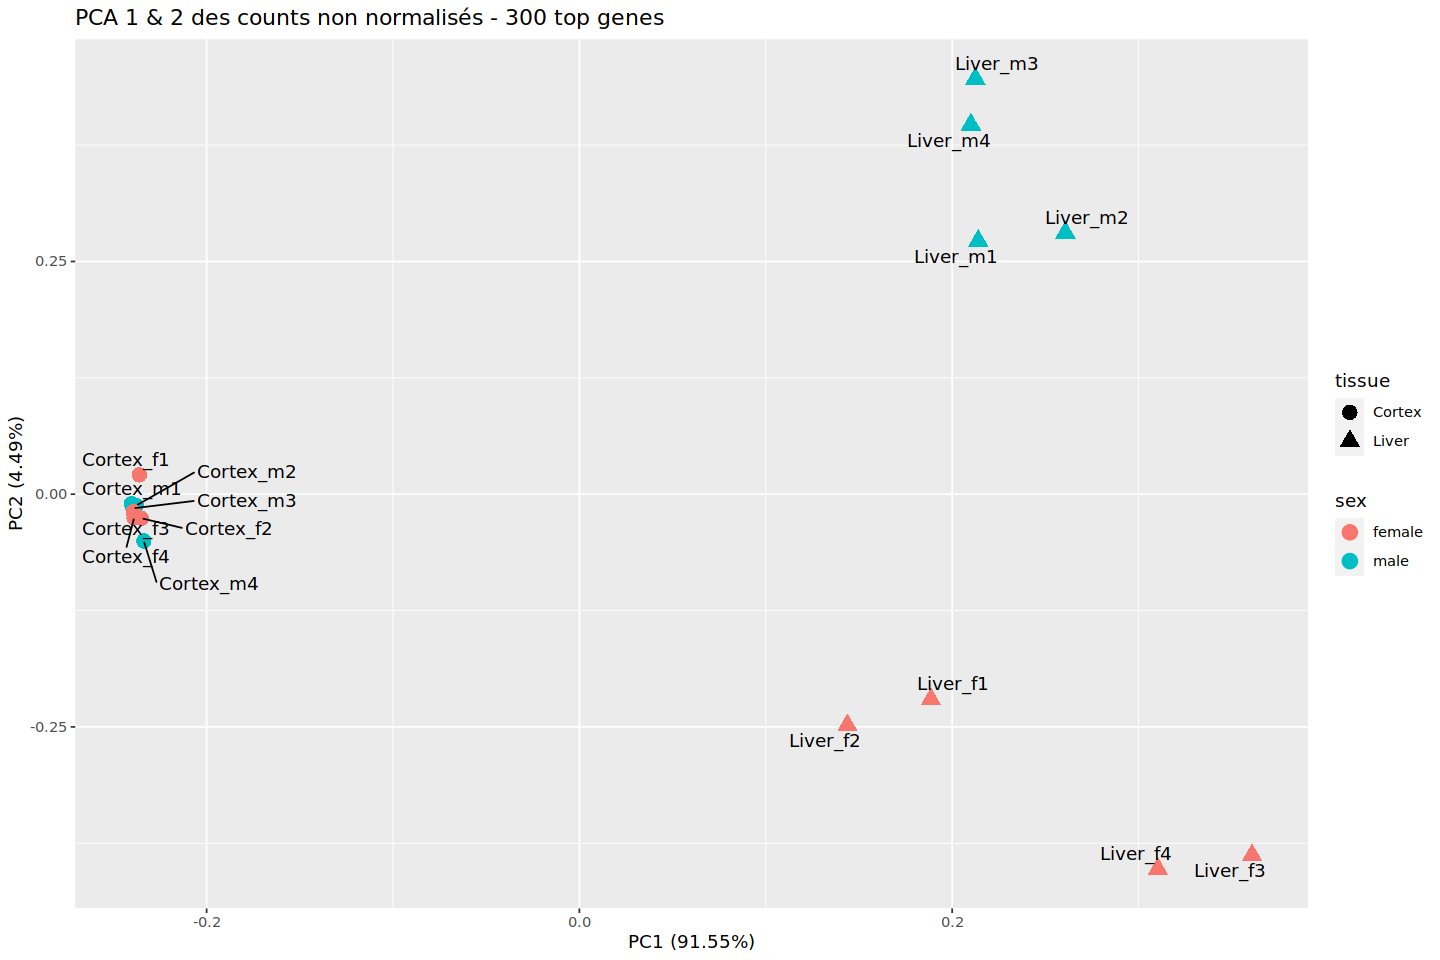

In [31]:
## Code cell 31 ##

options(repr.plot.width = 12, repr.plot.height = 8)

autoplot(PCAdata,
         data = metadata, 
         colour = "sex", 
         shape = "tissue",
         size = 4) +
        geom_text_repel(aes(x = PC1, y = PC2, label = sample_id), box.padding = 0.3, max.overlaps = 15) +
        labs(title = "PCA 1 & 2 des counts non normalisés - 300 top genes")


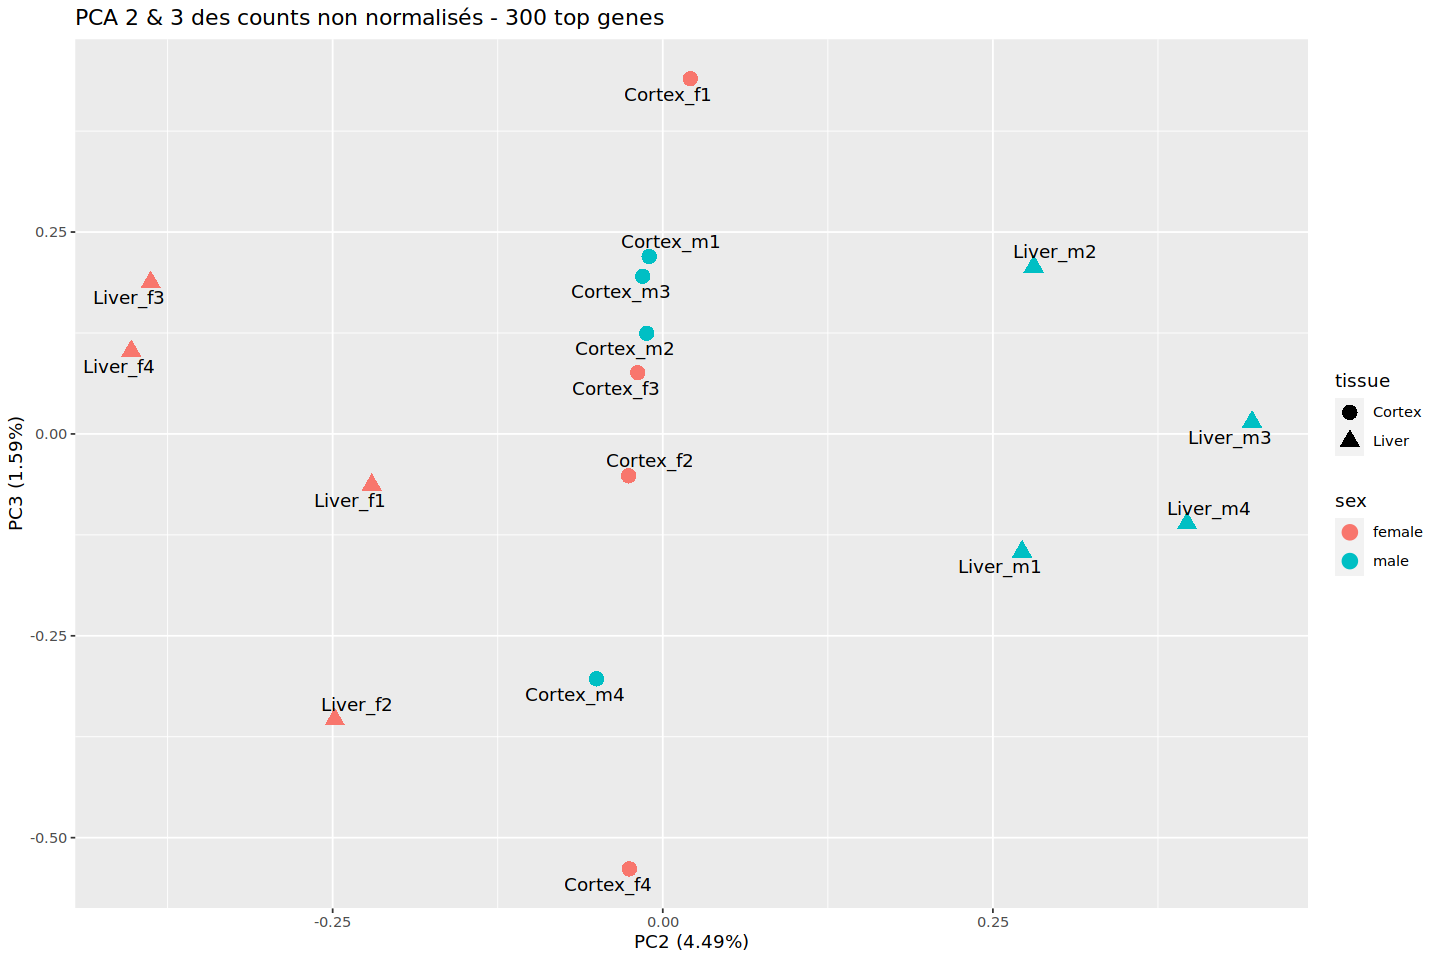

In [32]:
## Code cell 32 ##

options(repr.plot.width = 12, repr.plot.height = 8)

autoplot(PCAdata,
         x = 2,    # PC2
         y = 3,    # PC3
         data = metadata, 
         colour = "sex", 
         shape = "tissue",
         size = 4) +
        geom_text_repel(aes(x = PC2, y = PC3, label = sample_id), box.padding = 0.3, max.overlaps = 15) +
        labs(title = "PCA 2 & 3 des counts non normalisés - 300 top genes")



<div class="alert alert-block alert-info"> <b> Question 8 : </b><br>
<b> - La sélection des gènes les plus variables a t-elle changé vos conclusions à la suite de la question 7 ? <br>
    - D'après-vous pourquoi ? </b> </div>
___ 

### 2.E - Clustering hiérarchique

Il est également possible de visualiser la relation entre les échantillons à l'aide d'un clustering hiérachique.
On peut en tracer un avec les données filtrées, mais pas encore normalisées. 

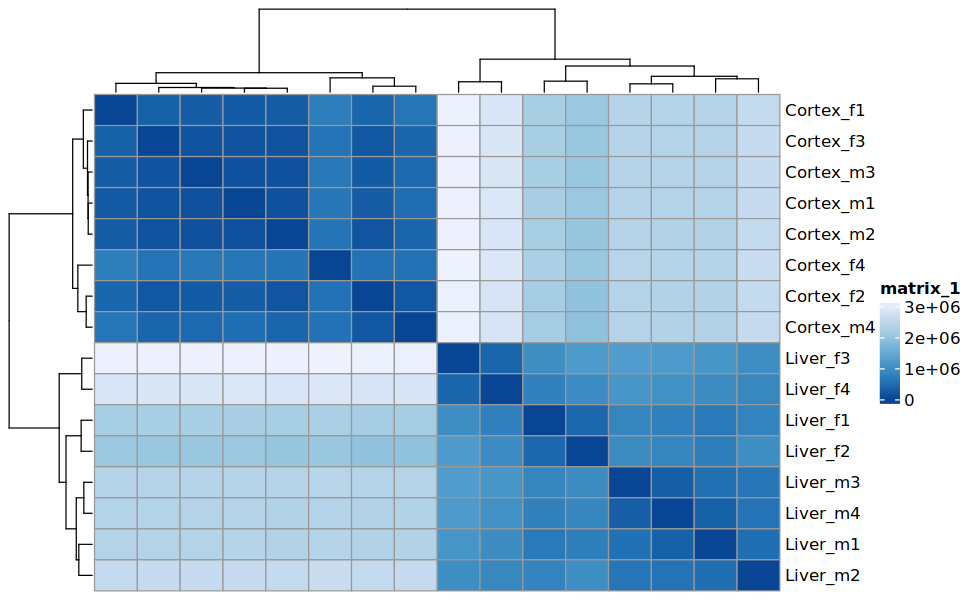

In [33]:
## Code cell 33 ##

options(repr.plot.width = 8, repr.plot.height = 5)


sampleDists <- dist(t(as.matrix(counts_filtered[, -c(1:2)])))

sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(metadata$sample_id)
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette(rev(brewer.pal(7, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)


_____

## 3. Création de l'objet DESeq2

Pour poursuivre l'analyse de nos données, il faut maintenant les normaliser, afin de corriger les variations entre comptages de reads qui ne sont pas dûes à des différence biologiques, mais à des paramètres expérimentaux : profondeurs de séquençage variables, faible détection des gènes faiblement exprimés, etc...   

Un des outils les plus utilisés en analyse RNAseq bulk est **DESeq2**.  
Il travaille à partir d'un objet R qui lui est propre, *DESeqDataSet*, qui est en général nommé `dds`, et qui stocke l'ensemble des données et des informations nécessaires à l'analyse. 

Nous créons l'objet DESeqDataSet avec les comptages, les métadonnées et le modèle statistique. Le modèle statistique inclut la ou les sources attendues de variations entre les échantillons. Ici dans notre cas, on suppose des variations selon le type de tissu et selon le sexe des souris comme facteurs principaux.

In [34]:
## Code cell 34 ##

# Préparer les informations des échantillons pour DESeq2
# et indiquer quels facteurs utiliser, avec leurs niveaux 
coldata <- data.frame(
    row.names = metadata$sample_name,
    tissue = factor(metadata$tissue, levels = c("Cortex", "Liver")),
    sex = factor(metadata$sex, levels = c("male", "female"))
)

# Afficher le résumé
summary(coldata)

    tissue      sex   
 Cortex:8   male  :8  
 Liver :8   female:8  

In [35]:
## Code cell 35 ##

# Créer l'objet DESeqDataSet
dds <- DESeqDataSetFromMatrix(countData = counts_filtered[ ,3:18],
                               colData = coldata,
                               design = ~ tissue + sex + tissue:sex)


cat("Données chargées et préparées\n")


Données chargées et préparées


Nous vérifions le nombre de genes dans le dataset

In [36]:
## Code cell 36 ##

nrow(dds)

[1] 26709

Et on affiche l'objet dds :

In [37]:
## Code cell 37 ##

dds

class: DESeqDataSet 
dim: 26709 16 
metadata(1): version
assays(1): counts
rownames(26709): 1 3 ... 77629 77769
rowData names(0):
colnames(16): Cortex_f1 Cortex_f2 ... Liver_f3 Liver_f4
colData names(2): tissue sex

Dans `dds`, les comptages sont rangés dans la portion "assays", qui est accessible avec la fonction `assay()` de DESeq2 : 

In [38]:
## Code cell 38 ##

head(assay(dds))

,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
1,1230,922,1228,1186,1268,666,1091,703,2825,2077,3016,3399,3293,3109,3010,2859
3,49,42,57,33,65,34,51,26,31,17,15,26,25,31,22,32
4,9,0,4,3,1,4,4,2,18,1808,5,169,7,3,7,8
5,74,61,59,62,53,33,52,36,1,4,0,2,1,2,6,6
6,7,8,10,11,16,11,5,4,39589,34224,51699,44869,43115,46534,53803,47560
7,1816,1273,1939,1783,1753,1051,1906,1067,1038,892,1541,2376,1483,1502,1464,1282


## 4. Normalisation des read counts

Les données de comptage présentes dans `assay(dds)`sont des nombres entiers : ce sont des données brutes non normalisées. 

Nous appliquons une transformation pour stabiliser la variance des comptages :
**vst** (variance stabilizing transformation), rapid et adaptée aux grands jeux de données

Cette transformation est nécessaire pour les analyses exploratoires comme l'ACP, car elles rendent les données plus homoscédastiques (variance constante quel que soitke niveau d'expression).

In [39]:
## Code cell 39 ##

# Transformation vst
vsd <- vst(dds, blind = TRUE)

cat("Transformation vst terminée\n")

Transformation vst terminée


On peut voir l'effet de la normalisation dans `assay(vsd)` :

In [40]:
## Code cell 40 ##

head(assay(vsd))

,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
1,9.562244,9.4681278,9.382469,9.593914,9.5244873,9.316089,9.308971,9.370682,11.919624,11.882215,12.0468492,12.157889,12.105859,12.073051,12.076567,11.961940
3,4.968168,5.0635693,5.007046,4.504438,5.2826501,5.075198,4.946065,4.681952,5.450739,5.005457,4.4768162,5.177181,5.116437,5.465585,5.035403,5.519666
4,2.746597,-0.6819837,1.721949,1.619055,0.6605221,2.318920,1.788724,1.583411,4.695317,11.682179,3.0377014,7.835366,3.402871,2.414190,3.492363,3.629318
5,5.543691,5.5854040,5.054938,5.377485,4.9984448,5.033715,4.972979,5.132249,1.298398,3.082056,-0.6819837,1.938622,1.277715,1.970283,3.294894,3.259367
6,2.451793,2.8734546,2.725261,3.062812,3.3905122,3.550994,2.018593,2.300820,15.727970,15.924203,16.1458769,15.880062,15.816198,15.976424,16.236025,16.017682
7,10.123583,9.9328218,10.040483,10.181337,9.9910833,9.973224,10.112656,9.971719,10.475979,10.663462,11.0784863,11.641483,10.955473,11.023931,11.037159,10.805380



<div class="alert alert-block alert-info"> <b> Question 9 : </b><br>
<b> - A quoi voyez-vous que les données ont été normalisées ? <br>
 </b> </div>
___ 

## 5. Visualisation des données normalisées 

### 5.A - Boxplot

Le même boxplot que précedemment sur les données normalisées : 

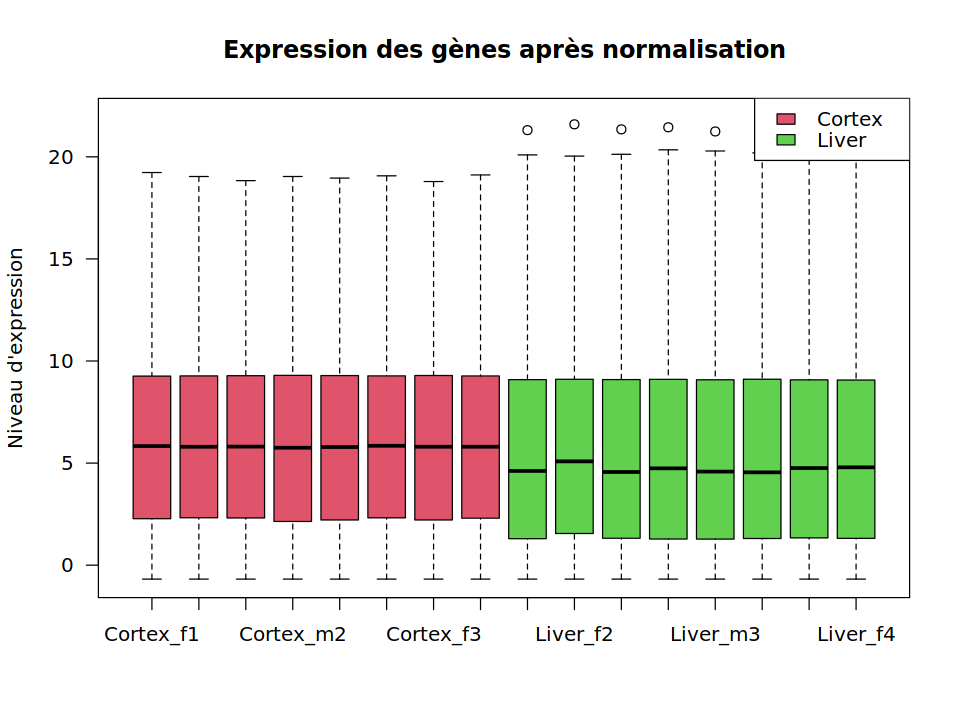

In [41]:
## Code cell n°41 ##

options(repr.plot.width = 8, repr.plot.height = 6)

# create a colour vector to color samples by tissue
tissueColor <- match(metadata$tissue, c("Cortex", "Liver")) + 1
# '+1' to avoid color '1' i.e. black

# Visualisation de la distribution des read counts filtrés par échantillon
boxplot(assay(vsd), na.rm=TRUE, 
        las = 1,    # allows to change the orientation of the axis labels: 1 is for always horizontal
        main = "Expression des gènes après normalisation",
        ylab = "Niveau d'expression",
        col = tissueColor)
legend("topright", 
       legend = levels(factor(metadata$tissue)),
       fill = 2:3)


<div class="alert alert-block alert-info"> <b> Question 10 : </b><br>
<b> - A quoi voyez-vous que les données ont été normalisées ? <br>
 </b> </div>
___ 

### 5.B - Clustering hiérarchique

On refait un clustering hiérachique avec les données normalisées par la fonction `vst`. 

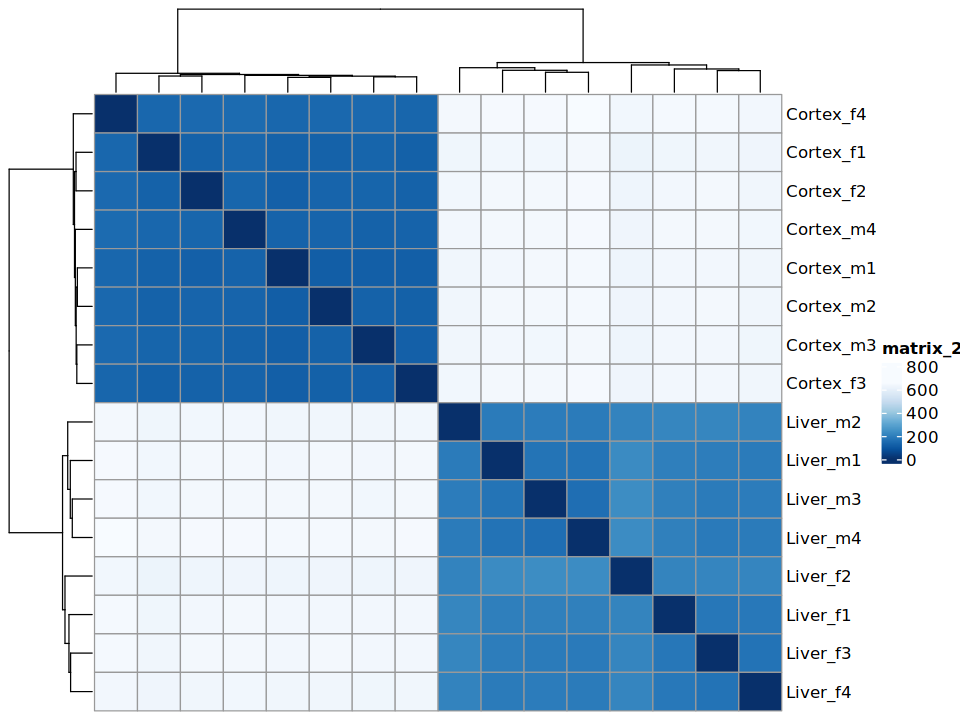

In [42]:
## Code cell 42 ##

sampleDists <- dist(t(assay(vsd)))

sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(metadata$sample_id)
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)


### 5.C - PCA avec DESeq2

La librairie `DESeq2` permet de faire directement une PCA sur des données RNA-seq.
Attention, toutefois :
- par défaut, seuls les 2 premiers axes sont sauvegardés.
- seuls les gènes les plus variables sont utilisés (par défaut : 500)

Par conséquence, les résultats seront différents d'une PCA "classique" qui aurait pris un nombre différent de top genes.

,PC1,PC2,group,tissue,name
,<dbl>,<dbl>,<fct>,<fct>,<chr>
Cortex_f1,-145.6962,0.110323657,Cortex,Cortex,Cortex_f1
Cortex_f2,-149.3861,-0.327280942,Cortex,Cortex,Cortex_f2
Cortex_m1,-148.5474,-0.002724209,Cortex,Cortex,Cortex_m1
Cortex_m2,-148.4002,-0.094182138,Cortex,Cortex,Cortex_m2
Cortex_m3,-148.6785,-0.283051622,Cortex,Cortex,Cortex_m3
Cortex_m4,-149.5634,0.091315126,Cortex,Cortex,Cortex_m4


[1] 0.98234707 0.01023099

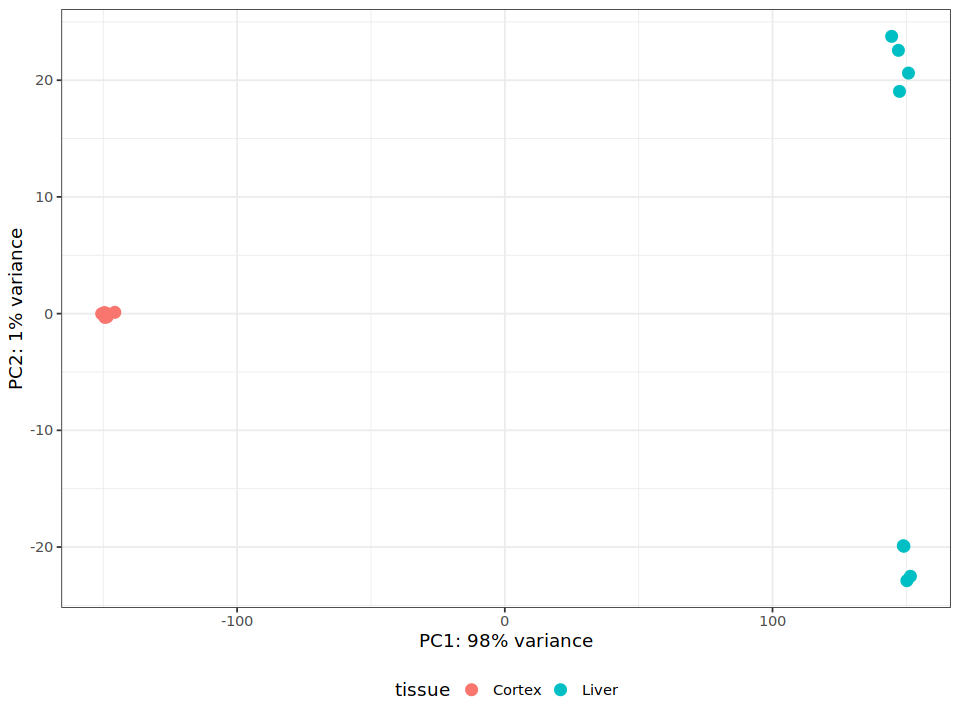

In [43]:
## Code cell 43 ##

pcaData <- DESeq2::plotPCA(vsd, 
                   intgroup=c("tissue"), 
                   returnData=TRUE)

head(pcaData)
attr(pcaData, "percentVar")

percentVar <- round(100 * attr(pcaData, "percentVar"))

options(repr.plot.width = 8, repr.plot.height = 6)

ggplot(pcaData, aes(PC1, PC2, color=tissue)) +
  geom_point(size=3) +
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
  theme_bw() +
  theme(legend.position="bottom", legend.key.height=unit(1,"line"), legend.key.width=unit(1,"line"))



## 6. Modélisation de la distribution des read counts

DESeq2 utilise un modèle linéaire généralisé (GLM) basé sur la distribution binomiale négative pour modéliser les read counts. Cette distribution est adaptée aux données de comptage qui présentent une surdispersion (variance supérieure à la moyenne).

Les étapes principales sont :
1. **Estimation des facteurs de taille** : normalisation pour les différences de profondeur de séquençage entre échantillons
2. **Estimation de la dispersion** : mesure de la variabilité biologique entre réplicats
3. **Test statistique** : identification des gènes différentiellement exprimés  

La fonction `DESeq()` exécute l'analyse DESeq2 complète avec les 3 étapes.   
Patientez, elle peut prendre un peu de temps. 

In [44]:
## Code cell 44 ##

# Cette fonction effectue les trois étapes : normalisation, estimation de la dispersion, et tests statistiques
dds2 <- DESeq2::DESeq(dds)

cat("Analyse DESeq2 terminée\n")

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Analyse DESeq2 terminée


Let's inspect the newly created object dds2. *(Note that in most tutorials, they often replace dds here. In fact, the dds object is completed with the results of the 3 steps. For clarity, we called the object dds2).*

In [45]:
## Code cell 45 ##

dds2

class: DESeqDataSet 
dim: 26709 16 
metadata(1): version
assays(4): counts mu H cooks
rownames(26709): 1 3 ... 77629 77769
rowData names(30): baseMean baseVar ... deviance maxCooks
colnames(16): Cortex_f1 Cortex_f2 ... Liver_f3 Liver_f4
colData names(3): tissue sex sizeFactor

The portion `assays` within `dds2` contains the expression data, still not normalized:

In [46]:
## Code cell 46 ##

head(assay(dds2))

,Cortex_f1,Cortex_f2,Cortex_m1,Cortex_m2,Cortex_m3,Cortex_m4,Cortex_f3,Cortex_f4,Liver_f1,Liver_f2,Liver_m1,Liver_m2,Liver_m3,Liver_m4,Liver_f3,Liver_f4
1,1230,922,1228,1186,1268,666,1091,703,2825,2077,3016,3399,3293,3109,3010,2859
3,49,42,57,33,65,34,51,26,31,17,15,26,25,31,22,32
4,9,0,4,3,1,4,4,2,18,1808,5,169,7,3,7,8
5,74,61,59,62,53,33,52,36,1,4,0,2,1,2,6,6
6,7,8,10,11,16,11,5,4,39589,34224,51699,44869,43115,46534,53803,47560
7,1816,1273,1939,1783,1753,1051,1906,1067,1038,892,1541,2376,1483,1502,1464,1282


### Plot de dispersion   

DESeq2 utilise le *shrinkage* pour corriger les estimations de log fold change (LogFC) des gènes peu exprimés, dont les valeurs pourraient sinon être artificiellement extrêmes à cause du faible nombre de lectures.   

*Par exemple, un gène qui aurait environ 5 reads dans une condition et 15 reads dans une autre pourrait apparaître comme surexprimé 3 fois dans la seconde condition. Cependant, il paraît évident que cette différence de read counts ne représente pas une vraie surexpression d'un point de vue biologique.*     

Cette méthode rapproche les LogFC des faibles read counts de zéro, évitant ainsi qu’ils dominent les résultats. La significativité d’un gène dépend non seulement de son LogFC, mais aussi de sa variabilité au sein des groupes, mesurée par la dispersion : pour les gènes fortement exprimés, une dispersion de 0,01 signifie par exemple une variabilité typique de 10 % entre répliquats (√0,01), tandis que pour les gènes faiblement exprimés, le bruit de Poisson augmente cette dispersion. La fonction `plotDispEsts` permet de visualiser ces estimations et l'effet de l'étape de *shrinkage*, aidant à évaluer la fiabilité des résultats.

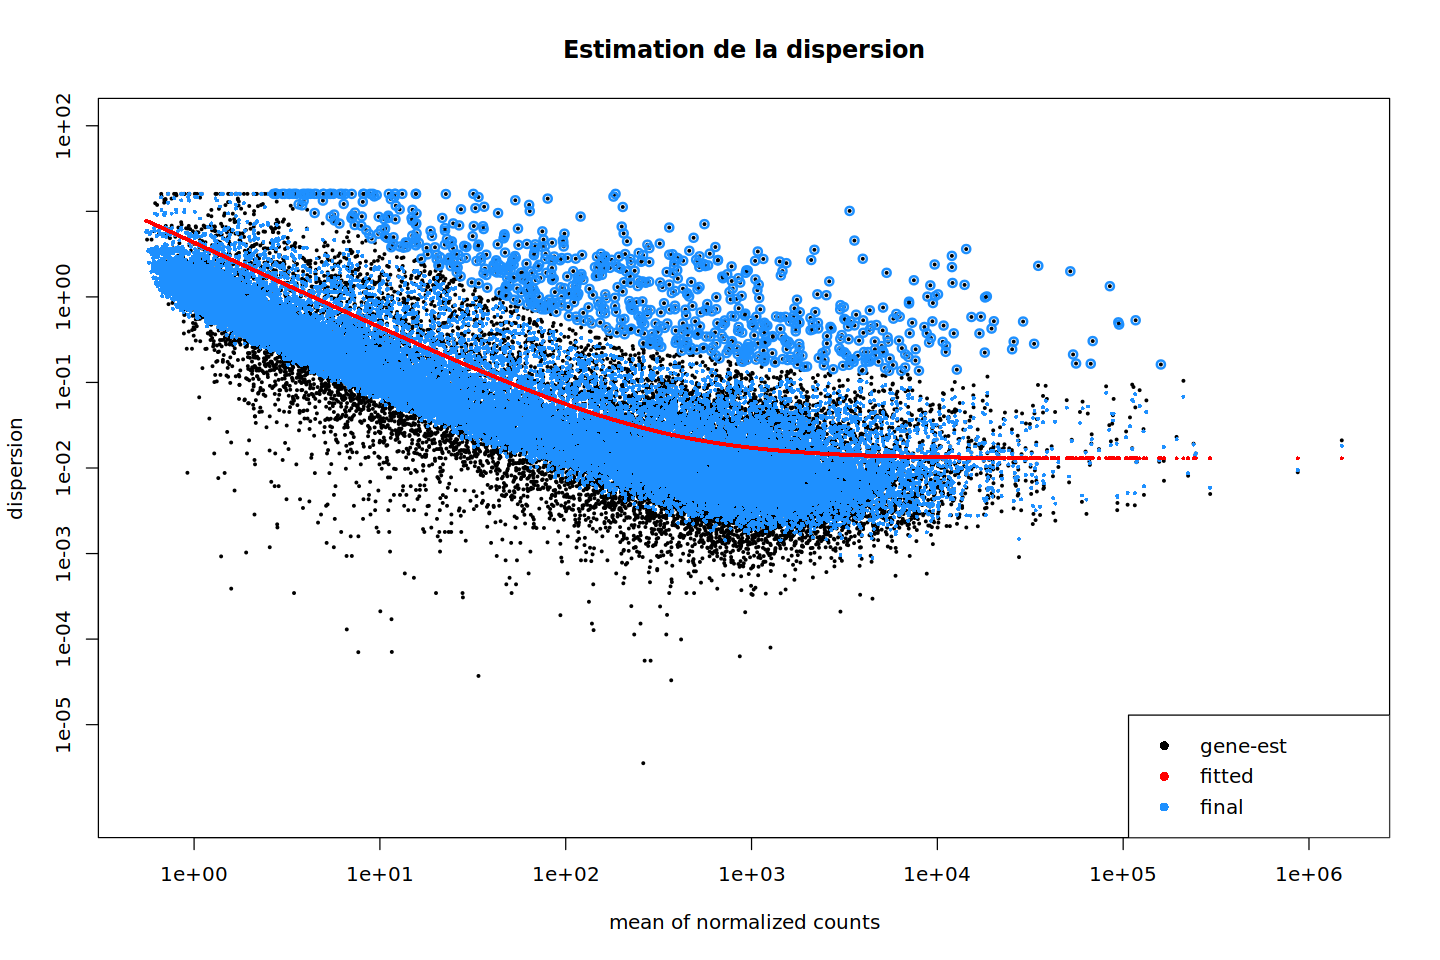

In [47]:
## Code cell 47 ##

# for figure display
options(repr.plot.width = 12, repr.plot.height = 8) 

# Visualiser la relation entre dispersion et moyenne d'expression
plotDispEsts(dds2, main = "Estimation de la dispersion" , ylim = c(1e-6, 1e2))

## 7. Analyse différentielle

### 7.A - Foie vs Cortex

Nous comparons les échantillons de Foie aux échantillons de Cortex pour identifier les gènes dont l'expression est modifiée par le type tissulaire.

In [48]:
## Code cell 48 ##

# Extraire les résultats pour le contraste (comparaison) Foie vs Cortex
res <- results(dds2, contrast = c("tissue", "Liver", "Cortex"))

# Afficher un résumé
summary(res)


out of 26709 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 8576, 32%
LFC < 0 (down)     : 11953, 45%
outliers [1]       : 219, 0.82%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### a - Utiliser un seuil différent : alpha 0.00001

Par défaut, la fonction `result` utilise un seuil de p-value ajustée (FDR) de 0.1. On peut utiliser un autre seuil de FDR, en définissant `alpha` de façon explicite.   
Le résultat précédent indique un nombre très important de gènes avec un LogFC non nul, on peut donc tester l'effet de diminuer le taux de faux positifs, avec `alpha=0,00001`.

In [49]:
## Code cell 49 ##

res2 <- results(dds2, contrast = c("tissue", "Liver", "Cortex"),  alpha = 0.0001)
summary(res2)


out of 26709 with nonzero total read count
adjusted p-value < 1e-04
LFC > 0 (up)       : 6379, 24%
LFC < 0 (down)     : 8211, 31%
outliers [1]       : 219, 0.82%
low counts [2]     : 2589, 9.7%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### b - Trier les gènes DE

In [50]:
## Code cell 50 ##

# Ordonner les résultats par p-valeur ajustée
res2_ordered <- res2[order(res2$padj), ]

# Afficher les 10 gènes les plus significatifs
head(res2_ordered, 10)

log2 fold change (MLE): tissue Liver vs Cortex 
Wald test p-value: tissue Liver vs Cortex 
DataFrame with 10 rows and 6 columns
     baseMean log2FoldChange     lfcSE      stat    pvalue      padj
    <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
6    32188.21       12.98936 0.2424554   53.5742         0         0
24    1995.79        9.06314 0.2251766   40.2490         0         0
54    5271.69        8.13089 0.1419104   57.2959         0         0
130  10927.70        7.24311 0.1101863   65.7351         0         0
197   9698.46        7.57795 0.1018439   74.4075         0         0
222   6148.10        8.56158 0.1250575   68.4612         0         0
224  15265.15       -7.82143 0.1386554  -56.4092         0         0
249  18238.77        8.57556 0.0796829  107.6212         0         0
293   4668.40        5.39224 0.0969038   55.6452         0         0
294   1872.16        5.42042 0.1303778   41.5747         0         0

#### c - Ajouter les noms de gènes   

On voit que les gènes sont identifiés par leur numéros, mais il est nécessaire d'avoir les noms de gènes pour la suite. On ajoute donc les noms des gènes dans le dataframe de résultats. 

In [51]:
## Code cell 51 ##

# 1. Convertir DESeqResults en data.frame
res2_df <- as.data.frame(res2)

# 2. Extraire les IDs des gènes différentiellement exprimés
de_gene_ids <- rownames(res2_df)

# 3. Créer un vecteur de noms de gènes correspondant aux IDs de res2
#    (en utilisant match() pour associer chaque ID à son nom)
gene_names <- counts_filtered$gene_name[match(de_gene_ids, rownames(counts_filtered))]

# 4. Ajouter la colonne gene_name au dataframe
res2_names <- cbind(res2_df, gene_name = gene_names)

# 5. Réorganiser les colonnes pour mettre gene_name au début
res2_names <- res2_names %>%
  dplyr::select(gene_name,baseMean, log2FoldChange, lfcSE, stat, pvalue, padj)

# 6. Vérifier qu'il n'y a pas de NA dans la colonne gene_name
sum(is.na(res2_names$gene_name))  # Doit retourner 0

# 7. Afficher les 10 premières lignes
head(res2_names, 10)


[1] 0

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Gnai3,2439.35759,2.6380175,0.07452354,35.3984455,1.804150e-274,6.484358e-273
3,Cdc45,32.55185,0.1120804,0.26729960,0.4193062,6.749924e-01,7.050209e-01
4,H19,224.79389,4.8785781,1.66689003,2.9267546,NA,NA
5,Scml2,20.19990,-4.3007812,0.69644756,-6.1753124,6.603277e-10,1.440403e-09
6,Apoh,32188.20899,12.9893566,0.24245541,53.5742075,0.000000e+00,0.000000e+00
7,Narf,1548.99151,1.1542403,0.14721888,7.8403011,4.494675e-15,1.189407e-14
8,Cav2,521.65730,-2.2381512,0.15018665,-14.9024645,3.176435e-50,1.826316e-49
9,Klf6,682.48859,-1.5439186,0.13679730,-11.2861776,1.535710e-29,5.956672e-29
10,Scmh1,647.74871,-1.2829013,0.09598847,-13.3651610,9.662573e-41,4.721839e-40


In [52]:
## Code cell 52 ##

# Ordonner les résultats par p-valeur ajustée
res2_ordered_names <- res2_names[order(res2_names$padj), ]

# Afficher les 10 gènes les plus significatifs
head(res2_ordered_names, 6)

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,Apoh,32188.209,12.989357,0.2424554,53.57421,0,0
24,Slc22a18,1995.793,9.063136,0.2251766,40.24901,0,0
54,Pemt,5271.692,8.130889,0.1419104,57.29595,0,0
130,Serpinf1,10927.697,7.243106,0.1101863,65.73511,0,0
197,Lgals9,9698.464,7.577954,0.1018439,74.40751,0,0
222,Hpn,6148.098,8.561581,0.1250575,68.46118,0,0


#### d - Sélectionner et afficher les gènes DE significatifs : Volcano Plot 

On sélectionne les gènes DE à la fois sur la p-value (ajustée, correction des tests multiples par la méthode Benjamini-Hochberg), et par le FC minimal.   
Rappel : 1 point de log2 FC correspond à une expression doublée ou réduite de moitié.   

In [53]:
## Code cell 53 ##

# Compter le nombre de gènes différentiellement exprimés (seuils : padj < 0.0001 et |log2FC| > 3)
sig_genes <- subset(res2_names, padj < 0.000001 & abs(log2FoldChange) > 4)

cat("Nombre de gènes différentiellement exprimés (Foie vs Cortex):", nrow(sig_genes), "\n")
cat("  - Sur-exprimés:", sum(sig_genes$log2FoldChange >= 4), "\n")
cat("  - Sous-exprimés:", sum(sig_genes$log2FoldChange <= -4), "\n")

Nombre de gènes différentiellement exprimés (Foie vs Cortex): 5289 
  - Sur-exprimés: 1862 
  - Sous-exprimés: 3427 


Warning message:
“Removed 2808 rows containing missing values (`geom_point()`).”


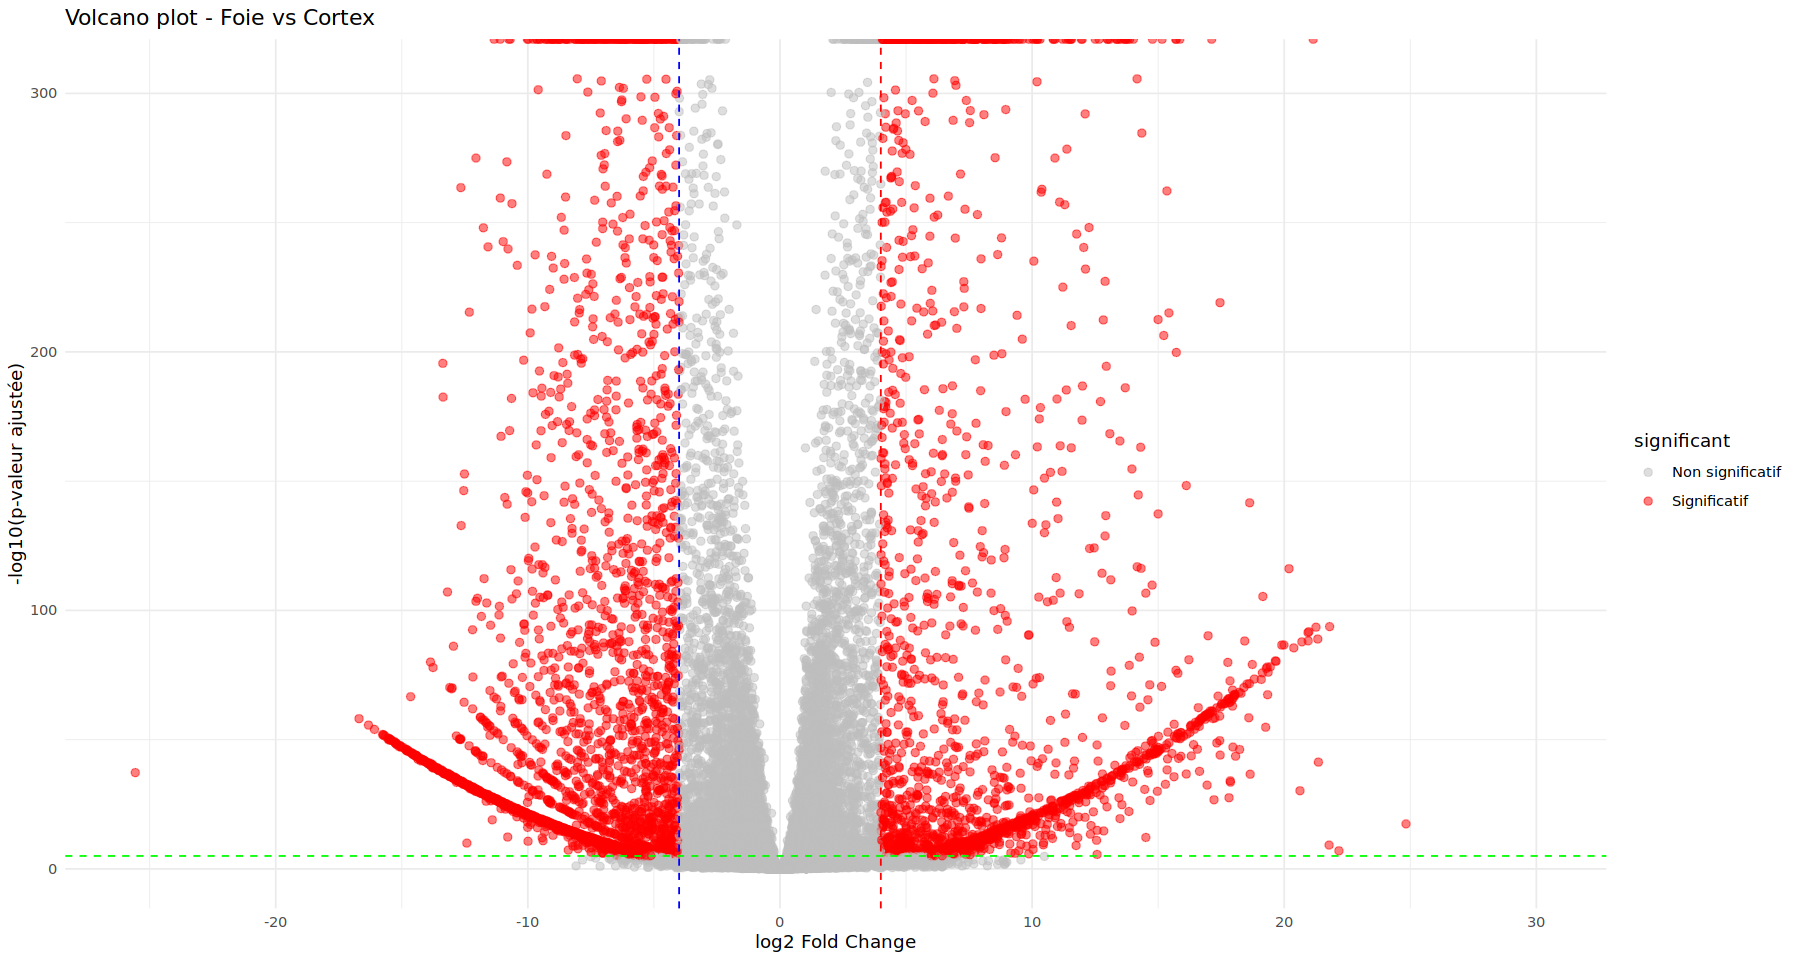

In [54]:
## Code cell 54 ##

# for figure display in the notebook
options(repr.plot.width = 15, repr.plot.height = 8) 

# Volcano plot pour visualiser les résultats
res2_names_df <- as.data.frame(res2_names)
res2_names_df$significant <- ifelse(res2_names_df$padj < 0.00001 & abs(res2_names_df$log2FoldChange) > 4, 
                                  "Significatif", "Non significatif")

ggplot(res2_names_df, aes(x = log2FoldChange, y = -log10(padj), color = significant)) +
    geom_point(alpha = 0.5, size = 2) +
    scale_color_manual(values = c("Non significatif" = "grey", "Significatif" = "red")) +
    geom_vline(xintercept = 4, linetype = "dashed", color = "red") +
    geom_vline(xintercept = -4, linetype = "dashed", color = "blue") +
    geom_hline(yintercept = -log10(0.00001), linetype = "dashed", color = "green") +
    labs(title = "Volcano plot - Foie vs Cortex",
         x = "log2 Fold Change",
         y = "-log10(p-valeur ajustée)") +
    theme_minimal()

Grâce au volcano plot, nous voyons que nous obtenons beaucoup de gènes DE car notre seuil de log2 FC est trop bas.   
On modifie donc notre seuil, et on refait le volcano plot. On en profite pour ajouter les noms des gènes gardés comme significativement DE. 

In [55]:
## Code cell 55 ##

# Compter le nombre de gènes différentiellement exprimés (seuils : padj < 0.00001 et |log2FC| > 4)
sig <- subset(res2_names, padj < 0.00001 & abs(log2FoldChange) > 10)

cat("Nombre de gènes différentiellement exprimés (Foie vs Cortex):", nrow(sig), "\n")
cat("  - Sur-exprimés:", sum(sig$log2FoldChange >= 10), "\n")
cat("  - Sous-exprimés:", sum(sig$log2FoldChange <= -10), "\n")

Nombre de gènes différentiellement exprimés (Foie vs Cortex): 1188 
  - Sur-exprimés: 487 
  - Sous-exprimés: 701 


Warning message:
“Removed 2808 rows containing missing values (`geom_point()`).”
Warning message:
“ggrepel: 5287 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


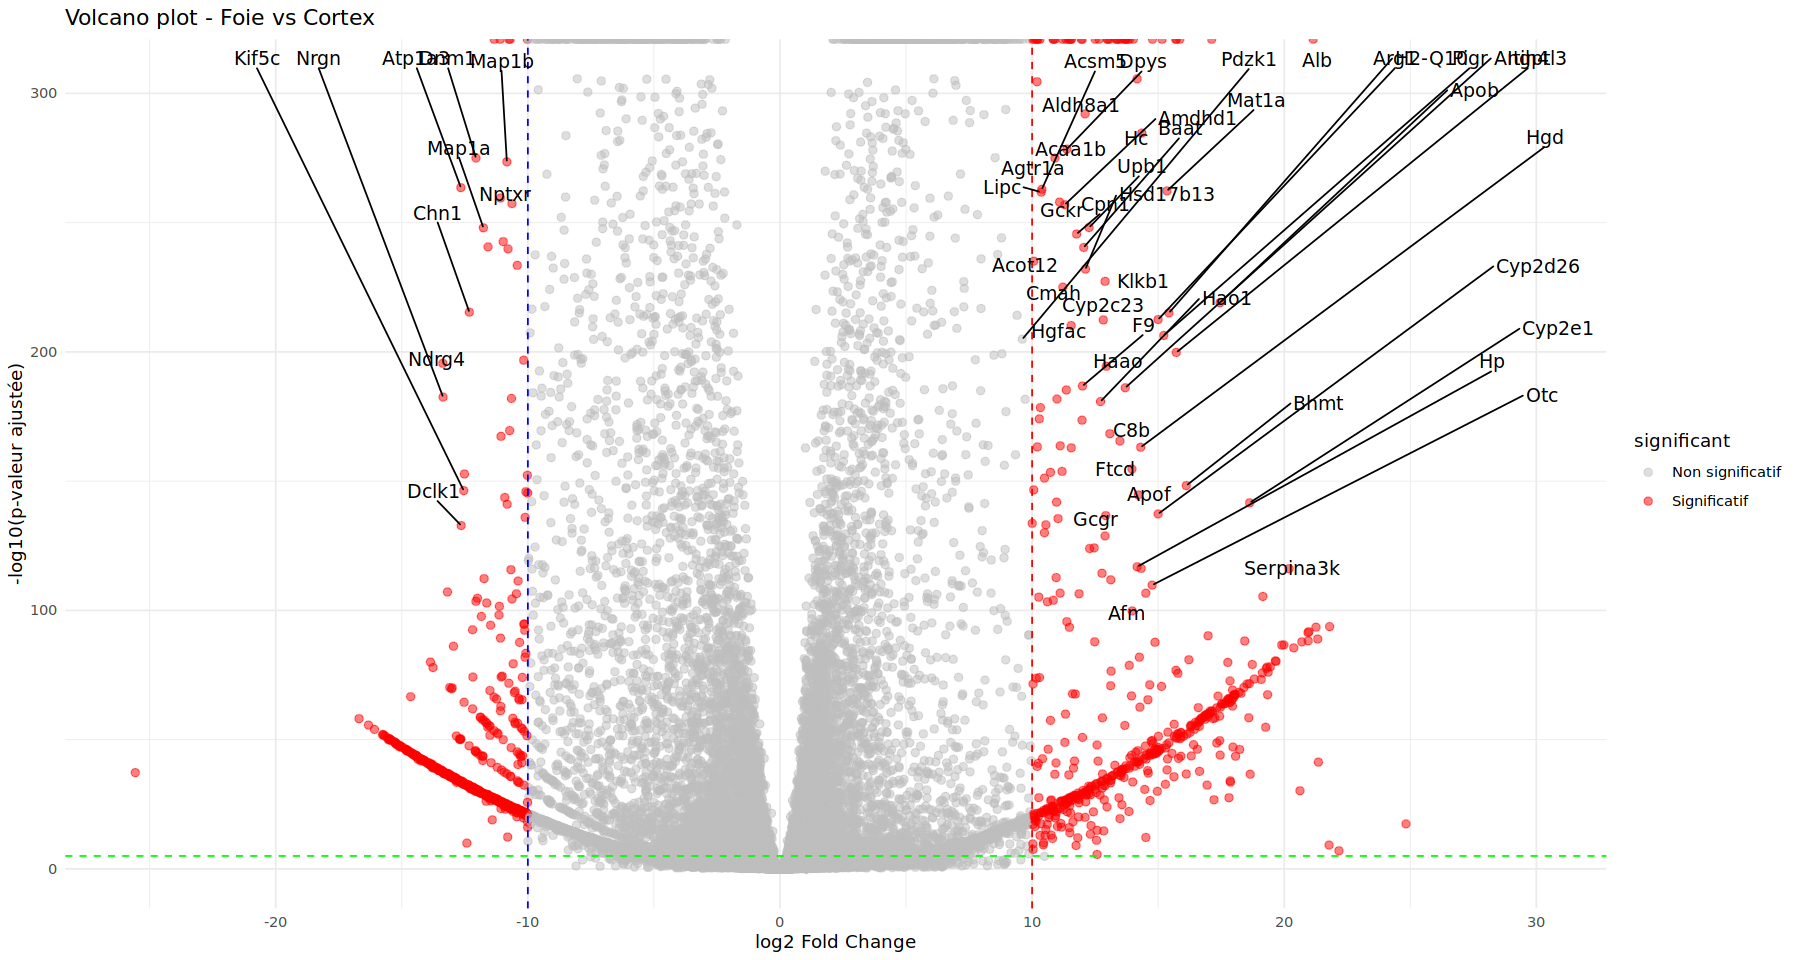

In [56]:
## Code cell 56 ##

# for figure display in the notebook
options(repr.plot.width = 15, repr.plot.height = 8) 

# Volcano plot pour visualiser les résultats
res2_names_df <- as.data.frame(res2_names)
res2_names_df$significant <- ifelse(res2_names_df$padj < 0.00001 & abs(res2_names_df$log2FoldChange) > 10, 
                                  "Significatif", "Non significatif")

ggplot(res2_names_df, aes(x = log2FoldChange, y = -log10(padj), color = significant)) +
    geom_point(alpha = 0.5, size = 2) +
    scale_color_manual(values = c("Non significatif" = "grey", "Significatif" = "red")) +
    geom_vline(xintercept = 10, linetype = "dashed", color = "red") +
    geom_vline(xintercept = -10, linetype = "dashed", color = "blue") +
    geom_hline(yintercept = -log10(0.00001), linetype = "dashed", color = "green") +
    # Ajouter les noms des gènes différentiellement exprimés (sig_dup)
    ggrepel::geom_text_repel(
        data = sig_genes,  # Utiliser directement le sous-ensemble sig_genes
        aes(label = gene_name),  # Étiqueter avec le nom du gène
        box.padding = 0.5,  # Éviter les chevauchements
        max.overlaps = 15,  # augmente le nombre de points étiquetés
        size = 4,  # Taille du texte
        color = "black"  # Couleur du texte
    ) +
    labs(title = "Volcano plot - Foie vs Cortex",
         x = "log2 Fold Change",
         y = "-log10(p-valeur ajustée)") +
    theme_minimal()

### 7.B - Mâles vs Femelles   

Nous avons vu grâce à la PCA qu'une petite part de la variance est expliquée par le sexe des souris.   
Nous allons donc refaire l'analyse DE sur ce facteur, identifier les gènes DE correspondant et refaire le volcano plot pertinent.   


<div class="alert alert-block alert-info"> <b> Question 11 : </b><br>
<b> - Au vu de la PCA, attendez-vous beaucoup ou peu de gènes DE selon ce facteur ? <br>
 </b> </div>
___ 

In [57]:
## Code cell 57 ##

# Extraire les résultats pour le contraste (comparaison) Female vs Male
res_sex <- results(dds2, contrast = c("sex", "female", "male"))

# Afficher un résumé
summary(res_sex)


out of 26709 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 7, 0.026%
LFC < 0 (down)     : 14, 0.052%
outliers [1]       : 219, 0.82%
low counts [2]     : 2589, 9.7%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### a - Utiliser un seuil différent : alpha 0.2
 
Le résultat précédent indique un nombre très faible de gènes avec un LogFC non nul, on peut donc tester l'effet de modifier le FDR, avec `alpha=0,2`.

In [58]:
## Code cell 58 ##

res2_sex <- results(dds2, contrast = c("sex", "female", "male"),  alpha = 0.2)
summary(res2_sex)


out of 26709 with nonzero total read count
adjusted p-value < 0.2
LFC > 0 (up)       : 11, 0.041%
LFC < 0 (down)     : 14, 0.052%
outliers [1]       : 219, 0.82%
low counts [2]     : 3105, 12%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### b - Trier les gènes DE

In [59]:
## Code cell 59 ##

# Ordonner les résultats par p-valeur ajustée
res2_sex_ordered <- res2_sex[order(res2_sex$padj), ]

# Afficher les 4 gènes les plus significatifs
head(res2_sex_ordered, 4)

log2 fold change (MLE): sex female vs male 
Wald test p-value: sex female vs male 
DataFrame with 4 rows and 6 columns
       baseMean log2FoldChange     lfcSE      stat      pvalue        padj
      <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
27300  9275.834        11.3631  0.275361   41.2661 0.00000e+00 0.00000e+00
19219   861.737       -13.0614  1.022659  -12.7720 2.34958e-37 2.74724e-33
19218   994.481       -12.9203  1.022735  -12.6330 1.38794e-36 1.08190e-32
16152   305.062       -12.0226  1.027144  -11.7049 1.20289e-31 7.03239e-28

#### c - Ajouter les noms de gènes   

In [60]:
## Code cell 60 ##

# 1. Convertir DESeqResults en data.frame
res2_sex_df <- as.data.frame(res2_sex)

# 2. Extraire les IDs des gènes différentiellement exprimés
de_gene_ids <- rownames(res2_sex_df)

# 3. Créer un vecteur de noms de gènes correspondant aux IDs de res2_sex
#    (en utilisant match() pour associer chaque ID à son nom)
gene_names <- counts_filtered$gene_name[match(de_gene_ids, rownames(counts_filtered))]

# 4. Ajouter la colonne gene_name au dataframe
res2_sex_names <- cbind(res2_sex_df, gene_name = gene_names)

# 5. Réorganiser les colonnes pour mettre gene_name au début
res2_sex_names <- res2_sex_names %>%
  dplyr::select(gene_name,baseMean, log2FoldChange, lfcSE, stat, pvalue, padj)

# 6. Vérifier qu'il n'y a pas de NA dans la colonne gene_name
sum(is.na(res2_sex_names$gene_name))  # Doit retourner 0

# 7. Afficher les 4 premières lignes
head(res2_sex_names, 4)

[1] 0

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Gnai3,2439.35759,-0.02945548,0.0770386,-0.3823470,0.7022040,0.9999098
3,Cdc45,32.55185,-0.06949225,0.2503931,-0.2775326,0.7813712,0.9999098
4,H19,224.79389,0.21934328,1.7089054,0.1283531,NA,NA
5,Scml2,20.19990,0.21429384,0.2796043,0.7664184,0.4434274,0.9999098


In [61]:
## Code cell 61 ##

# Ordonner les résultats par p-valeur ajustée
res2_sex_ordered_names <- res2_sex_names[order(res2_sex_names$padj), ]

# Afficher les 10 gènes les plus significatifs
head(res2_sex_ordered_names, 10)

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27300,Xist,9275.83440,11.3630520,0.27536071,41.266062,0.000000e+00,0.000000e+00
19219,Eif2s3y,861.73683,-13.0614318,1.02265934,-12.772026,2.349577e-37,2.747243e-33
19218,Ddx3y,994.48140,-12.9202677,1.02273548,-12.633049,1.387937e-36,1.081897e-32
16152,Kdm5d,305.06182,-12.0226234,1.02714373,-11.704909,1.202889e-31,7.032391e-28
19114,Uty,237.97111,-10.4818385,1.02856431,-10.190747,2.180822e-24,1.019971e-20
7014,Masp2,4372.27057,-2.7178621,0.30767322,-8.833600,1.013599e-18,3.950503e-15
9917,Eif2s3x,3618.22229,0.6401024,0.07319569,8.745083,2.228519e-18,7.444845e-15
16658,Eno1b,2202.62180,-6.4444201,0.83760191,-7.693894,1.427236e-14,4.171990e-11
34757,Gm29650,14.22638,-7.9023455,1.06700205,-7.406120,1.300479e-13,3.379079e-10



<div class="alert alert-block alert-info"> <b> Question 12 : </b><br>
<b> - Quel gène vous semble logiquement DE entre les femelles et les mâles ? <br>
    - Le sens du Fold Change vous semble t'il logique ?
 </b> </div>
___ 

#### d - Sélectionner et afficher les gènes DE significatifs : Volcano Plot 

Nous utilisons des seuils beaucoup moins stringents que pour la première analyse DE. 

In [62]:
## Code cell 62 ##

# Compter le nombre de gènes différentiellement exprimés (seuils : padj < 0.05 et |log2FC| > 1)
sig_genes_sex <- subset(res2_sex_names, padj < 0.05 & abs(log2FoldChange) > 1)

cat("Nombre de gènes différentiellement exprimés (Female vs Male):", nrow(sig_genes), "\n")
cat("  - Sur-exprimés:", sum(sig_genes$log2FoldChange >= 1), "\n")
cat("  - Sous-exprimés:", sum(sig_genes$log2FoldChange <= -1), "\n")

Nombre de gènes différentiellement exprimés (Female vs Male): 5289 
  - Sur-exprimés: 1862 
  - Sous-exprimés: 3427 


Warning message:
“Removed 3324 rows containing missing values (`geom_point()`).”


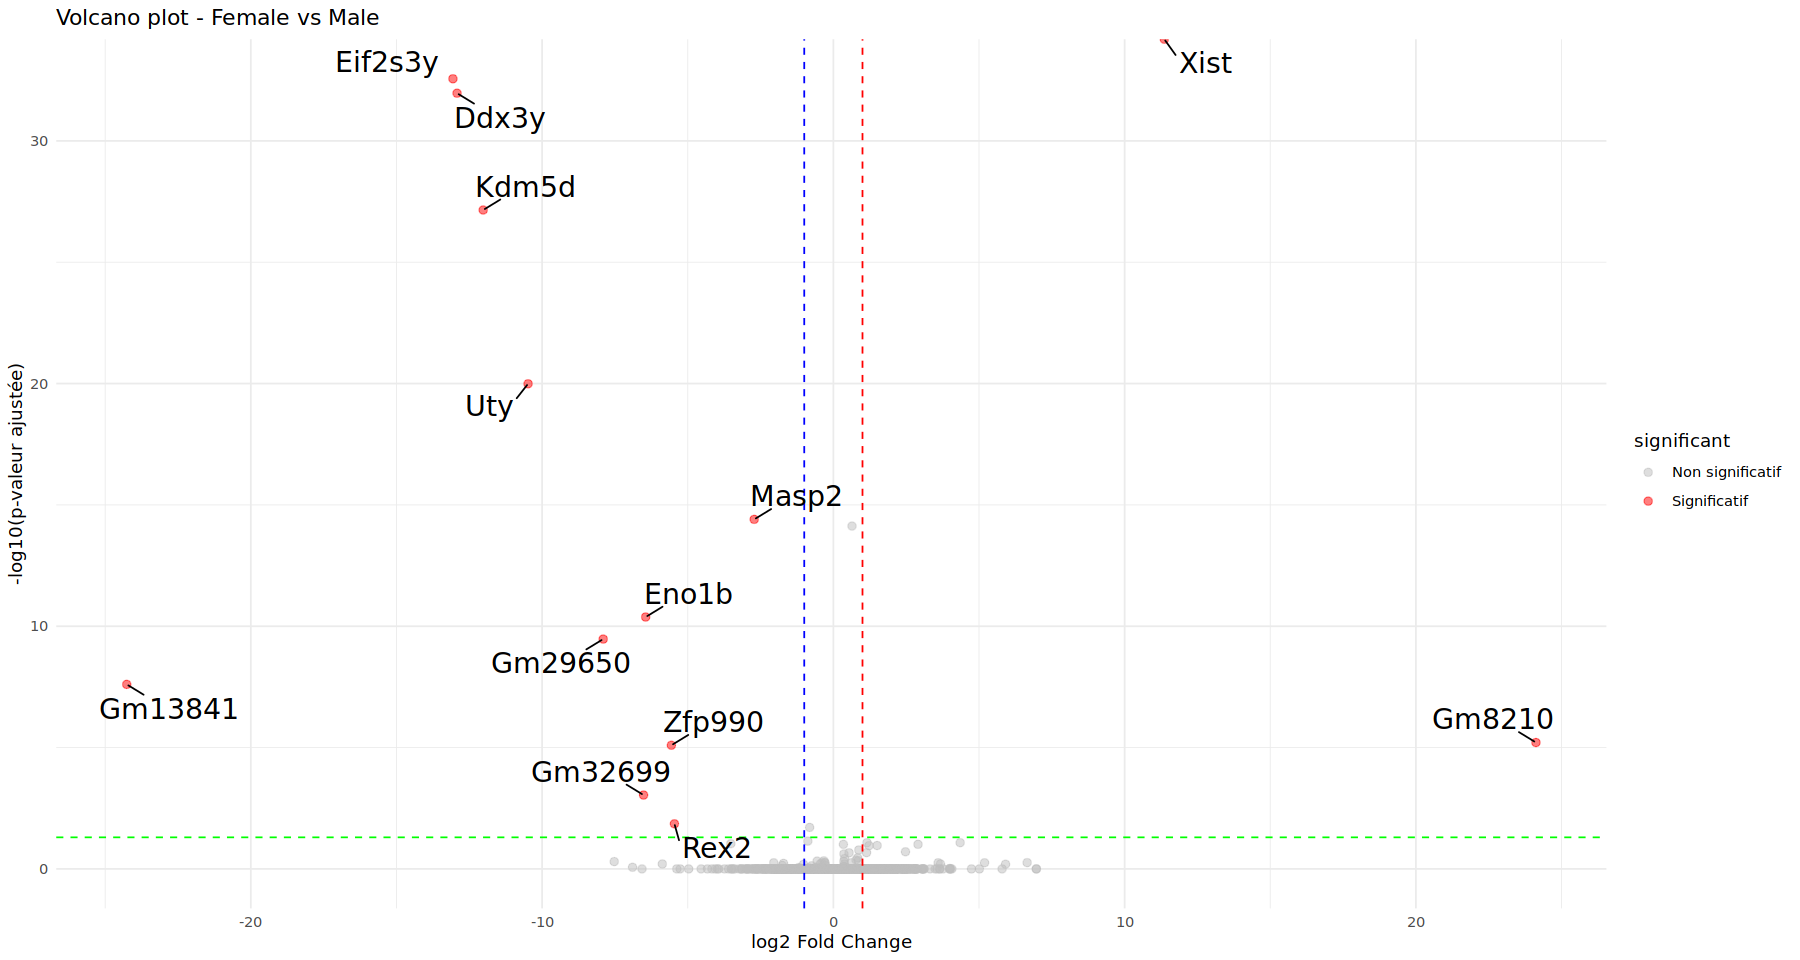

In [63]:
## Code cell 63 ##

# for figure display in the notebook
options(repr.plot.width = 15, repr.plot.height = 8) 

# Volcano plot pour visualiser les résultats
res2_sex_names_df <- as.data.frame(res2_sex_names)
res2_sex_names_df$significant <- ifelse(res2_sex_names_df$padj < 0.05 & abs(res2_sex_names_df$log2FoldChange) > 1, 
                                  "Significatif", "Non significatif")

ggplot(res2_sex_names_df, aes(x = log2FoldChange, y = -log10(padj), color = significant)) +
    geom_point(alpha = 0.5, size = 2) +
    scale_color_manual(values = c("Non significatif" = "grey", "Significatif" = "red")) +
    geom_vline(xintercept = 1, linetype = "dashed", color = "red") +
    geom_vline(xintercept = -1, linetype = "dashed", color = "blue") +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "green") +
    # Ajouter les noms des gènes différentiellement exprimés (sig_dup)
    ggrepel::geom_text_repel(
        data = sig_genes_sex,  # Utiliser directement le sous-ensemble sig_dup
        aes(label = gene_name),  # Étiqueter avec le nom du gène
        box.padding = 0.5,  # Éviter les chevauchements
        max.overlaps = 20,  # augmente le nombre de points étiqutés
        size = 6,  # Taille du texte
        color = "black"  # Couleur du texte
    ) +
    labs(title = "Volcano plot - Female vs Male",
         x = "log2 Fold Change",
         y = "-log10(p-valeur ajustée)") +
    theme_minimal()

## 8. Sauvegarde des résultats

Nous sauvegardons les tableaux de résultats pour une analyse ultérieure.

In [64]:
## Code cell 64 ##
dim(res2_ordered_names)
head(res2_ordered_names) 
dim(sig_genes)
head(sig_genes)

dim(res2_sex_ordered_names)
head(res2_sex_ordered_names) 
dim(sig_genes_sex)
head(sig_genes_sex)

[1] 26709     7

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,Apoh,32188.209,12.989357,0.2424554,53.57421,0,0
24,Slc22a18,1995.793,9.063136,0.2251766,40.24901,0,0
54,Pemt,5271.692,8.130889,0.1419104,57.29595,0,0
130,Serpinf1,10927.697,7.243106,0.1101863,65.73511,0,0
197,Lgals9,9698.464,7.577954,0.1018439,74.40751,0,0
222,Hpn,6148.098,8.561581,0.1250575,68.46118,0,0


[1] 5289    7

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,Scml2,20.19990,-4.300781,0.6964476,-6.175312,6.603277e-10,1.440403e-09
6,Apoh,32188.20899,12.989357,0.2424554,53.574208,0.000000e+00,0.000000e+00
16,Wnt3,24.38427,-7.630711,1.0491094,-7.273513,3.502562e-13,8.692217e-13
17,Wnt9a,276.32381,-4.300529,0.2207252,-19.483636,1.511552e-84,1.358181e-83
24,Slc22a18,1995.79256,9.063136,0.2251766,40.249008,0.000000e+00,0.000000e+00
26,Igsf5,502.04106,7.403494,0.2670675,27.721438,3.851754e-169,6.916662e-168


[1] 26709     7

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27300,Xist,9275.8344,11.363052,0.2753607,41.26606,0.000000e+00,0.000000e+00
19219,Eif2s3y,861.7368,-13.061432,1.0226593,-12.77203,2.349577e-37,2.747243e-33
19218,Ddx3y,994.4814,-12.920268,1.0227355,-12.63305,1.387937e-36,1.081897e-32
16152,Kdm5d,305.0618,-12.022623,1.0271437,-11.70491,1.202889e-31,7.032391e-28
19114,Uty,237.9711,-10.481839,1.0285643,-10.19075,2.180822e-24,1.019971e-20
7014,Masp2,4372.2706,-2.717862,0.3076732,-8.83360,1.013599e-18,3.950503e-15


[1] 13  7

,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7014,Masp2,4372.270572,-2.717862,0.3076732,-8.833600,1.013599e-18,3.950503e-15
16152,Kdm5d,305.061821,-12.022623,1.0271437,-11.704909,1.202889e-31,7.032391e-28
16658,Eno1b,2202.621798,-6.444420,0.8376019,-7.693894,1.427236e-14,4.171990e-11
19002,Rex2,3.742737,-5.457048,1.2240575,-4.458163,8.266516e-06,1.380803e-02
19114,Uty,237.971113,-10.481839,1.0285643,-10.190747,2.180822e-24,1.019971e-20
19218,Ddx3y,994.481395,-12.920268,1.0227355,-12.633049,1.387937e-36,1.081897e-32


In [65]:
## Code cell 65 ##

# Sauvegarder les résultats complets
write.table(as.data.frame(res2_ordered_names), 
            file = "DESeq2_Liver_vs_Cortex_allgenes.txt",
            sep = "\t", quote = FALSE, row.names = TRUE)

write.table(as.data.frame(res2_sex_ordered_names), 
            file = "DESeq2_Female_vs_Male_allgenes.txt",
            sep = "\t", quote = FALSE, row.names = TRUE)

# Sauvegarder uniquement les gènes significatifs
write.table(as.data.frame(sig_genes), 
            file = "DESeq2_Liver_vs_Cortex_significant.txt",
            sep = "\t", quote = FALSE, row.names = TRUE)

write.table(as.data.frame(sig_genes_sex), 
            file = "DESeq2_Female_vs_Male_significant.txt",
            sep = "\t", quote = FALSE, row.names = TRUE)

cat("Résultats sauvegardés\n")

Résultats sauvegardés


Maj 17/02/2026 - SCaburet